# Laboratorio 4 -- Parte 2. Modelos con datos geoespaciales

Universidad del Valle de Guatemala. CC3084 Data Science, Semestre II 2026.

Fernando Rueda -- 23748. Fernando Hernández -- 23645.

En esta segunda parte reutilizamos las imágenes Sentinel-2 de la Parte 1 para
construir modelos de aprendizaje automático que identifiquen zonas con alta
presencia de cianobacteria. Este avance cubre la preparación de los datos, la
construcción de la variable respuesta y la selección de variables predictoras.
Cada observación es un píxel de agua de alguno de los dos lagos en una de las
once fechas oficiales.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# raíz del repositorio, funcione desde notebooks/ o desde la raíz
ROOT = Path.cwd()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA_RAW = ROOT / "data" / "raw"
DATA_PROC = ROOT / "data" / "processed"

# reutilizamos las fechas oficiales y el umbral definidos en la Parte 1
sys.path.append(str(ROOT / "src"))
from config import LAGOS, UMBRAL_CIANO_ALTO

SEMILLA = 23748
N_MUESTRA = 4000              # píxeles de agua por escena
CLASES_NUBE = (3, 8, 9, 10, 11)  # sombra, nubes y cirros en la banda SCL

print("lagos:", list(LAGOS))
print("umbral de cianobacteria (Parte 1):", UMBRAL_CIANO_ALTO)

lagos: ['atitlan', 'amatitlan']
umbral de cianobacteria (Parte 1): 0.1


## Ejercicio 1. Preparación de los datos para Machine Learning

### 1.1 Construcción del conjunto de datos

Cada fila del conjunto de datos representa un píxel de agua válido dentro de uno
de los lagos en una fecha concreta. Los rasters de la Parte 1 vienen en el
sistema de coordenadas UTM zona 15N (EPSG:32615), cuyas unidades son metros, así
que guardamos directamente el este y el norte de cada píxel junto con su
longitud y latitud. Como cada escena tiene cientos de miles de píxeles de agua,
tomamos una muestra aleatoria de hasta cuatro mil píxeles por escena, igual para
ambos lagos, para que el conjunto sea manejable y ninguno de los dos lagos
domine el entrenamiento.

In [2]:
from pyproj import Transformer

# transformador de UTM 15N a longitud y latitud, para tener ambas coordenadas
a_lonlat = Transformer.from_crs("EPSG:32615", "EPSG:4326", always_xy=True)
rng = np.random.default_rng(SEMILLA)


def observaciones_escena(clave, fecha):
    """Devuelve un DataFrame con los píxeles de agua muestreados de una escena."""
    raw = xr.open_dataset(DATA_RAW / clave / f"{fecha}.nc").squeeze(drop=True)
    proc = xr.open_dataset(DATA_PROC / clave / f"{fecha}.nc")

    scl = raw["SCL"].values
    agua = proc["agua"].values
    ndci = proc["cyano"].values
    ndvi = proc["ndvi"].values
    ndwi = proc["ndwi"].values

    # píxel válido: agua, sin nube ni sombra, con índices finitos
    valido = agua & ~np.isin(scl, CLASES_NUBE)
    valido &= np.isfinite(ndci) & np.isfinite(ndvi) & np.isfinite(ndwi)

    idx = np.flatnonzero(valido.ravel())
    n_validos = idx.size
    if n_validos > N_MUESTRA:
        idx = rng.choice(idx, N_MUESTRA, replace=False)

    xx, yy = np.meshgrid(raw["x"].values, raw["y"].values)
    este = xx.ravel()[idx]
    norte = yy.ravel()[idx]
    lon, lat = a_lonlat.transform(este, norte)

    def toma(a):
        return a.ravel()[idx]

    df = pd.DataFrame({
        "lago": clave,
        "fecha": fecha,
        "este": este,
        "norte": norte,
        "lon": lon,
        "lat": lat,
        # bandas en reflectancia (los valores digitales de Sentinel-2 son x10000)
        "B03": toma(raw["B03"].values) / 10000.0,
        "B04": toma(raw["B04"].values) / 10000.0,
        "B05": toma(raw["B05"].values) / 10000.0,
        "B08": toma(raw["B08"].values) / 10000.0,
        "ndvi": toma(ndvi),
        "ndwi": toma(ndwi),
        "ndci": toma(ndci),
    })
    return df, n_validos


registros = []
resumen_limpieza = []
for clave in LAGOS:
    for fecha in LAGOS[clave]["fechas"]:
        ruta = DATA_PROC / clave / f"{fecha}.nc"
        if not ruta.exists():
            continue
        df, n_validos = observaciones_escena(clave, fecha)
        registros.append(df)
        resumen_limpieza.append({"lago": clave, "fecha": fecha,
                                 "agua_valida": n_validos, "muestreadas": len(df)})

datos = pd.concat(registros, ignore_index=True)
print("observaciones totales:", len(datos))

observaciones totales: 88000


### 1.2 Variables incluidas

El conjunto incluye las coordenadas de cada observación como este y norte en
metros y también como longitud y latitud, la fecha y el lago, las bandas
espectrales B03, B04, B05 y B08 en reflectancia, y los índices NDVI, NDWI y
NDCI. El NDCI es el índice de cianobacteria y lo conservamos porque a partir de
él construiremos la variable respuesta, aunque por esa misma razón más adelante
no podrá usarse como predictor.

In [3]:
print("dimensiones:", datos.shape)
datos.head()

dimensiones: (88000, 13)


,lago,fecha,este,norte,lon,lat,B03,B04,B05,B08,ndvi,ndwi,ndci
0,atitlan,2025-01-18,698135.0,1624055.0,-91.159974,14.682851,0.0085,0.0009,0.0002,0.0011,0.100000,0.770833,-0.636364
1,atitlan,2025-01-18,701885.0,1625885.0,-91.125021,14.699109,0.0142,0.0021,0.0238,0.0059,0.475000,0.412935,0.837838
2,atitlan,2025-01-18,692185.0,1628105.0,-91.214913,14.719882,0.0089,0.0006,0.0002,0.0011,0.294118,0.780000,-0.500000
3,atitlan,2025-01-18,688985.0,1625945.0,-91.244782,14.700589,0.0086,0.0008,0.0003,0.0020,0.428571,0.622642,-0.454545
4,atitlan,2025-01-18,693655.0,1623765.0,-91.201585,14.680556,0.0087,0.0005,0.0007,0.0004,-0.111111,0.912088,0.166667


### 1.3 Limpieza de observaciones

Antes de muestrear descartamos todo lo que no es agua útil. Nos quedamos solo
con los píxeles marcados como agua por la máscara de la Parte 1, quitamos los
píxeles clasificados como nube, sombra o cirro en la banda SCL, y exigimos que
los índices tengan valores finitos, lo que elimina los píxeles sin datos y los
valores no válidos. La siguiente tabla muestra, por escena, cuántos píxeles de
agua válida quedaron disponibles y cuántos tomamos en la muestra.

In [4]:
limpieza = pd.DataFrame(resumen_limpieza)
limpieza

,lago,fecha,agua_valida,muestreadas
0,atitlan,2025-01-18,277578,4000
1,atitlan,2025-04-13,1233733,4000
2,atitlan,2025-05-13,1231075,4000
3,atitlan,2025-07-17,1205765,4000
4,atitlan,2025-11-21,1010525,4000
5,atitlan,2025-12-29,1129555,4000
6,atitlan,2026-02-12,964842,4000
7,atitlan,2026-03-24,1231216,4000
8,atitlan,2026-04-13,1227405,4000
9,atitlan,2026-04-28,1230163,4000


### 1.4 Resumen del conjunto de datos

Reportamos el número total de observaciones, cuántas corresponden a cada lago y
a cada fecha, las variables disponibles con su tipo y el porcentaje de valores
faltantes de cada una.

In [5]:
print("total de observaciones:", len(datos))
print("\nobservaciones por lago:")
print(datos["lago"].value_counts())
print("\nobservaciones por lago y fecha:")
print(datos.groupby(["lago", "fecha"]).size().to_string())

total de observaciones: 88000

observaciones por lago:
lago
atitlan      44000
amatitlan    44000
Name: count, dtype: int64

observaciones por lago y fecha:
lago       fecha     
amatitlan  2025-01-28    4000
           2025-04-15    4000
           2025-04-28    4000
           2025-11-24    4000
           2026-01-08    4000
           2026-02-02    4000
           2026-02-07    4000
           2026-03-29    4000
           2026-04-13    4000
           2026-04-28    4000
           2026-06-19    4000
atitlan    2025-01-18    4000
           2025-04-13    4000
           2025-05-13    4000
           2025-07-17    4000
           2025-11-21    4000
           2025-12-29    4000
           2026-02-12    4000
           2026-03-24    4000
           2026-04-13    4000
           2026-04-28    4000
           2026-07-22    4000


In [6]:
resumen_vars = pd.DataFrame({
    "tipo": datos.dtypes.astype(str),
    "pct_faltantes": (datos.isna().mean() * 100).round(2),
})
resumen_vars

,tipo,pct_faltantes
lago,object,0.0
fecha,object,0.0
este,float64,0.0
norte,float64,0.0
lon,float64,0.0
lat,float64,0.0
B03,float32,0.0
B04,float32,0.0
B05,float32,0.0
B08,float32,0.0


### 1.5 Análisis exploratorio

Exploramos las variables que entrarán a los modelos. Miramos la distribución de
las bandas y de los índices, comparamos el índice de cianobacteria entre los dos
lagos y revisamos cómo se relacionan las variables entre sí.

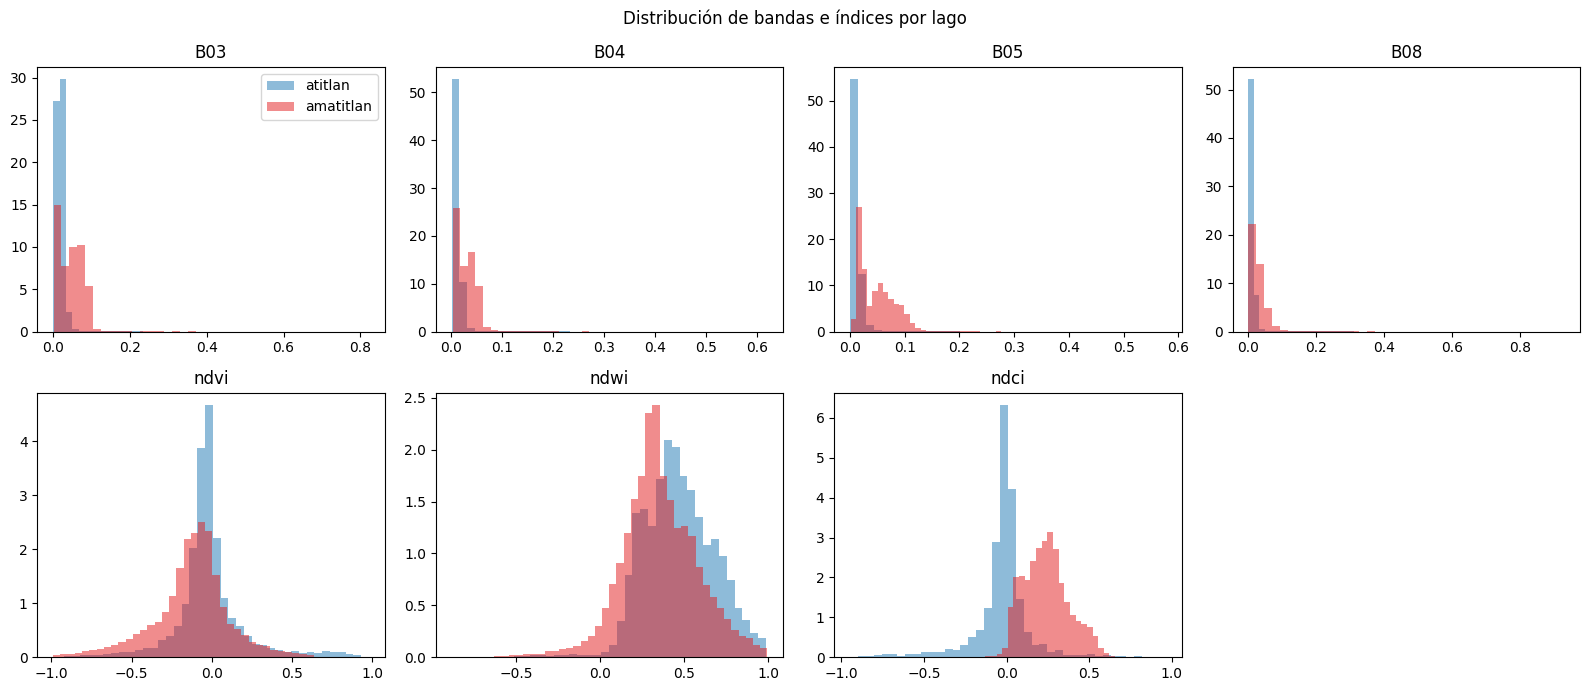

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), ["B03", "B04", "B05", "B08", "ndvi", "ndwi", "ndci"]):
    for clave, color in [("atitlan", "#1f78b4"), ("amatitlan", "#e31a1c")]:
        ax.hist(datos[datos["lago"] == clave][col], bins=40, alpha=0.5,
                color=color, label=clave, density=True)
    ax.set_title(col)
axes.ravel()[-1].axis("off")
axes.ravel()[0].legend()
fig.suptitle("Distribución de bandas e índices por lago")
fig.tight_layout()
plt.show()

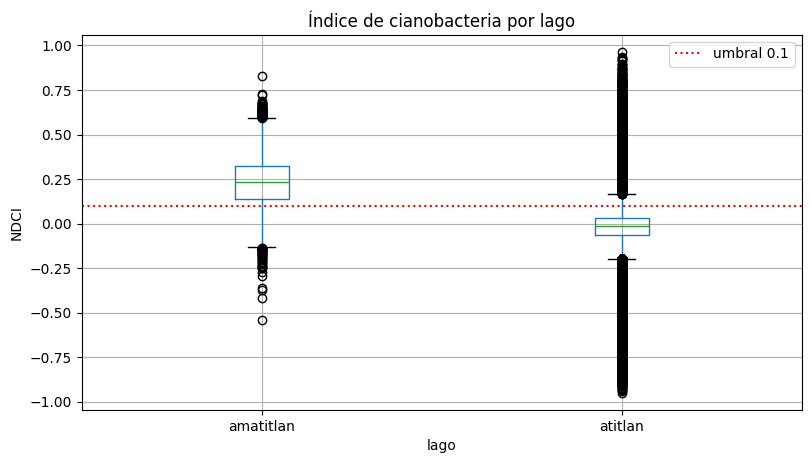

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
datos.boxplot(column="ndci", by="lago", ax=ax)
ax.axhline(UMBRAL_CIANO_ALTO, color="red", ls=":", label=f"umbral {UMBRAL_CIANO_ALTO}")
ax.set_title("Índice de cianobacteria por lago")
ax.set_ylabel("NDCI")
ax.legend()
plt.suptitle("")
plt.show()

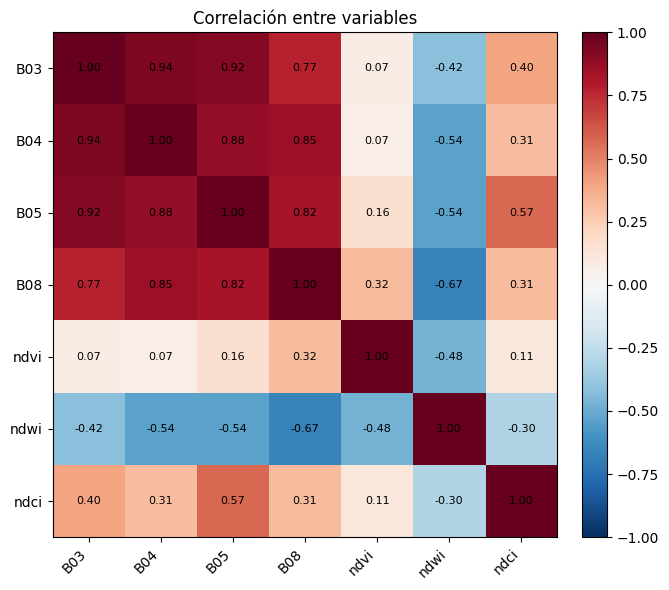

In [9]:
cols = ["B03", "B04", "B05", "B08", "ndvi", "ndwi", "ndci"]
corr = datos[cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)), cols, rotation=45, ha="right")
ax.set_yticks(range(len(cols)), cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlación entre variables")
fig.tight_layout()
plt.show()

La exploración confirma lo que ya veíamos en la Parte 1. El índice de
cianobacteria es mucho más alto en Amatitlán que en Atitlán, y sus
distribuciones apenas se solapan, lo que anticipa que la variable respuesta
estará muy asociada al lago. Entre las variables espectrales, el NDCI se
relaciona de forma positiva con el NDVI y negativa con el NDWI, y las bandas
del rojo y del borde rojo comparten bastante información entre sí.

### 1.6 Decisiones de preparación y limpieza

Tomamos varias decisiones para que el conjunto sea representativo y manejable.
Muestreamos hasta cuatro mil píxeles de agua por escena con una semilla fija, de
modo que el resultado sea reproducible y que ambos lagos aporten la misma
cantidad de observaciones por fecha pese a que Atitlán es mucho más grande que
Amatitlán. Convertimos las bandas a reflectancia dividiendo entre diez mil, que
es la escala nativa de Sentinel-2, sin que eso afecte a los índices porque son
cocientes. Conservamos las coordenadas en metros y en grados para poder
reconstruir mapas y armar bloques espaciales más adelante. Finalmente dejamos
fuera del conjunto los píxeles de tierra, de nube, de sombra y sin datos, así
como el píxel de una escena de Atitlán con un bloque grande de datos faltantes
que ya habíamos detectado en la Parte 1.

## Ejercicio 2. Construcción de la variable respuesta

### 2.1 Variable respuesta binaria

Construimos una variable respuesta binaria a partir del índice de cianobacteria.
Marcamos con uno los píxeles con alta presencia de cianobacteria y con cero los
de ausencia o baja presencia. Como punto de corte usamos el mismo umbral de la
Parte 1, y dejamos la justificación formal de ese valor con base en bibliografía
científica para el inciso 2.2, que corresponde a la otra parte del grupo. Al
final guardamos el conjunto completo con la etiqueta para que el resto de los
ejercicios parta de la misma base.

In [10]:
datos["alta_cianobacteria"] = (datos["ndci"] > UMBRAL_CIANO_ALTO).astype(int)

print("distribución de la variable respuesta:")
print(datos["alta_cianobacteria"].value_counts())
print("\nproporción de clase alta:", round(datos["alta_cianobacteria"].mean(), 3))
datos[["lago", "fecha", "ndci", "alta_cianobacteria"]].head()

distribución de la variable respuesta:
alta_cianobacteria
0    47338
1    40662
Name: count, dtype: int64

proporción de clase alta: 0.462


,lago,fecha,ndci,alta_cianobacteria
0,atitlan,2025-01-18,-0.636364,0
1,atitlan,2025-01-18,0.837838,1
2,atitlan,2025-01-18,-0.500000,0
3,atitlan,2025-01-18,-0.454545,0
4,atitlan,2025-01-18,0.166667,1


In [11]:
# guardamos el conjunto para que la parte de 2.2 en adelante use la misma base
destino = DATA_PROC / "dataset_ml.csv"
datos.to_csv(destino, index=False)
print("conjunto guardado en", destino.relative_to(ROOT), "con", len(datos), "observaciones")

conjunto guardado en data/processed/dataset_ml.csv con 88000 observaciones


### 2.2 Justificación del punto de corte

Partimos del conjunto guardado en el inciso anterior, de modo que esta sección y
las siguientes usen exactamente la misma base.

In [12]:
datos = pd.read_csv(DATA_PROC / "dataset_ml.csv")
print("observaciones:", len(datos), "| columnas:", list(datos.columns))

observaciones: 88000 | columnas: ['lago', 'fecha', 'este', 'norte', 'lon', 'lat', 'B03', 'B04', 'B05', 'B08', 'ndvi', 'ndwi', 'ndci', 'alta_cianobacteria']


El índice de cianobacteria que usamos es el NDCI (*Normalized Difference
Chlorophyll Index*), calculado con las bandas del rojo (B04, 665 nm) y del borde
rojo (B05, 705 nm). Mishra y Mishra (2012) lo propusieron precisamente para
estimar clorofila-a en aguas turbias y productivas, y es la base del script de
detección de cianobacteria de Sentinel Hub que reprodujimos en la Parte 1. En su
trabajo, los autores calibraron el índice contra mediciones de campo y
reportaron una correspondencia aproximada entre rangos de NDCI y concentración de
clorofila-a: valores menores a −0.1 corresponden a menos de 7.5 mg/m³, entre −0.1
y 0 a 7.5–16 mg/m³, entre 0 y 0.1 a 16–25 mg/m³, entre 0.1 y 0.2 a 25–33 mg/m³, y
por encima de 0.2 a más de 33 mg/m³.

La Organización Mundial de la Salud define niveles de alerta para cianobacterias
en aguas recreativas en función de la clorofila-a cuando las cianobacterias
dominan el fitoplancton: el nivel de vigilancia se activa alrededor de 12 µg/L y
el nivel de alerta 2, en el que se recomienda restringir el contacto con el agua,
cerca de 24 µg/L (OMS, 2021; Chorus y Welker, 2021). Un NDCI de 0.1 equivale,
según la calibración de Mishra y Mishra, a unos 25 mg/m³ de clorofila-a, es
decir, justo al nivel en que la OMS considera que la floración ya representa un
riesgo para la salud. Por eso mantenemos como punto de corte el umbral de 0.1
que ya usamos en la Parte 1: por debajo de él el agua puede tener clorofila pero
no en concentraciones que la OMS considere de alerta, y por encima hablamos de
una floración con presencia alta de cianobacteria.

La siguiente tabla muestra cómo cambiaría la proporción de observaciones
positivas si moviéramos el umbral. La proporción cambia de forma gradual, sin
saltos bruscos, de modo que la elección no es un punto crítico del análisis; con
0.1 ambos lagos conservan observaciones de las dos clases, algo que con umbrales
más bajos se pierde en Amatitlán, donde casi todo quedaría marcado como
positivo, y con umbrales más altos se pierde en Atitlán, donde la clase positiva
quedaría reducida a unos pocos píxeles.

In [13]:
umbrales = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]
sensibilidad = pd.DataFrame({
    "umbral_ndci": umbrales,
    "clorofila_aprox_mg_m3": ["16", "~20", "~25", "~29", "~33", "~45"],
    "pct_positivos_global": [round(100 * (datos["ndci"] > u).mean(), 1) for u in umbrales],
    "pct_positivos_atitlan": [round(100 * (datos.loc[datos["lago"] == "atitlan", "ndci"] > u).mean(), 1) for u in umbrales],
    "pct_positivos_amatitlan": [round(100 * (datos.loc[datos["lago"] == "amatitlan", "ndci"] > u).mean(), 1) for u in umbrales],
})
sensibilidad

,umbral_ndci,clorofila_aprox_mg_m3,pct_positivos_global,pct_positivos_atitlan,pct_positivos_amatitlan
0,0.00,16,69.6,40.2,98.9
1,0.05,~20,55.5,18.3,92.7
2,0.10,~25,46.2,10.1,82.3
3,0.15,~29,39.8,6.9,72.7
4,0.20,~33,32.3,4.8,59.8
5,0.30,~45,16.6,3.1,30.0


**Referencias.** Mishra, S. y Mishra, D. R. (2012). Normalized difference
chlorophyll index: A novel model for remote estimation of chlorophyll-a
concentration in turbid productive waters. *Remote Sensing of Environment*, 117,
394–406. — Organización Mundial de la Salud (2021). *Guidelines on recreational
water quality. Volume 1: Coastal and fresh waters*. Ginebra: OMS. — Chorus, I. y
Welker, M. (eds.) (2021). *Toxic Cyanobacteria in Water* (2.ª ed.). CRC Press /
OMS. — Sentinel Hub (s. f.). Cyanobacteria detection custom script.
https://custom-scripts.sentinel-hub.com

### 2.3 Distribución de la variable respuesta

Revisamos cómo se reparte la etiqueta en todo el conjunto, en cada lago y en
cada fecha, porque de esa distribución dependen tanto el desbalance como la
forma en que tendremos que separar entrenamiento y prueba.

In [14]:
resp = datos["alta_cianobacteria"]
print("distribución global:")
print(pd.DataFrame({"observaciones": resp.value_counts().sort_index(),
                    "porcentaje": (100 * resp.value_counts(normalize=True).sort_index()).round(1)}))

por_lago = datos.groupby("lago")["alta_cianobacteria"].agg(
    observaciones="size", positivos="sum", pct_positivos=lambda s: round(100 * s.mean(), 1))
print("\npor lago:")
print(por_lago)

distribución global:
                    observaciones  porcentaje
alta_cianobacteria                           
0                           47338        53.8
1                           40662        46.2

por lago:
           observaciones  positivos  pct_positivos
lago                                              
amatitlan          44000      36228           82.3
atitlan            44000       4434           10.1


In [15]:
por_fecha = (datos.groupby(["lago", "fecha"])["alta_cianobacteria"]
             .agg(observaciones="size", positivos="sum", pct_positivos=lambda s: round(100 * s.mean(), 1))
             .reset_index())
por_fecha

,lago,fecha,observaciones,positivos,pct_positivos
0,amatitlan,2025-01-28,4000,3921,98.0
1,amatitlan,2025-04-15,4000,2032,50.8
2,amatitlan,2025-04-28,4000,2416,60.4
3,amatitlan,2025-11-24,4000,3415,85.4
4,amatitlan,2026-01-08,4000,3849,96.2
5,amatitlan,2026-02-02,4000,2451,61.3
6,amatitlan,2026-02-07,4000,3668,91.7
7,amatitlan,2026-03-29,4000,3840,96.0
8,amatitlan,2026-04-13,4000,3948,98.7
9,amatitlan,2026-04-28,4000,2750,68.8


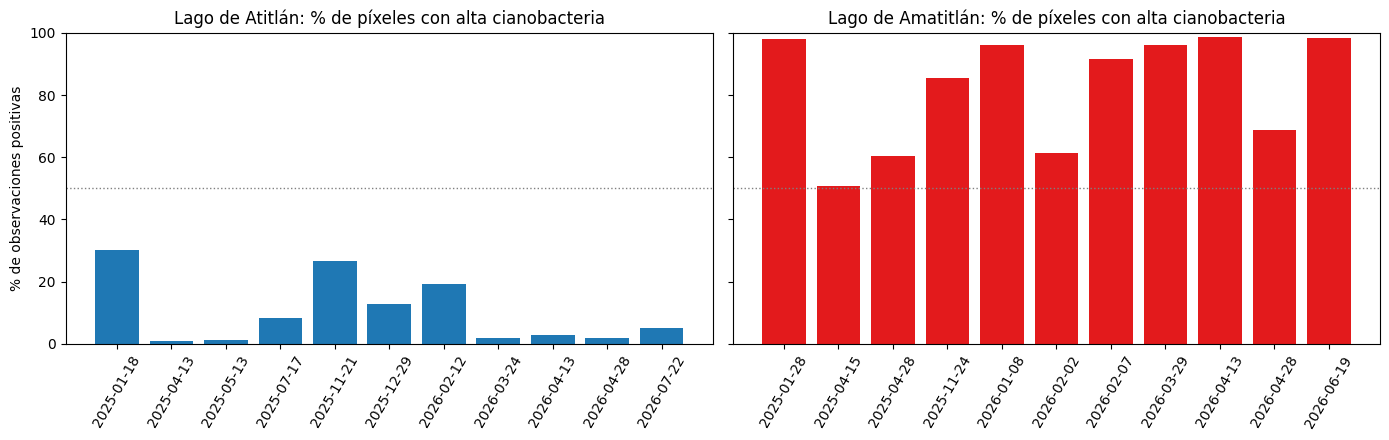

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, (clave, color) in zip(axes, [("atitlan", "#1f78b4"), ("amatitlan", "#e31a1c")]):
    sub = por_fecha[por_fecha["lago"] == clave]
    ax.bar(sub["fecha"], sub["pct_positivos"], color=color)
    ax.axhline(50, color="gray", ls=":", lw=1)
    ax.set_title(f"{LAGOS[clave]['nombre']}: % de píxeles con alta cianobacteria")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=60)
axes[0].set_ylabel("% de observaciones positivas")
fig.tight_layout()
plt.show()

A nivel global la respuesta luce equilibrada, pero esa cifra esconde que la
etiqueta está muy asociada al lago: en Amatitlán la gran mayoría de los píxeles
supera el umbral en casi todas las fechas, mientras que en Atitlán la clase
positiva es minoritaria y se concentra en unas pocas fechas. Dentro de cada lago
la proporción de positivos también cambia entre fechas, lo que refleja los picos
y descensos de floración que describimos en el análisis temporal de la Parte 1.
Esto implica que el desbalance relevante no es el global sino el que aparece al
mirar cada lago y cada fecha por separado, y es lo que analizamos a continuación.

### 2.4 Desbalance de clases y sus consecuencias

Medimos el desbalance con la razón entre la clase mayoritaria y la minoritaria.
Lo calculamos para todo el conjunto, para cada lago y para cada escena, porque
ya vimos que el equilibrio global es engañoso.

In [17]:
def razon_desbalance(s):
    """Razón mayoritaria/minoritaria; inf si solo hay una clase."""
    n1, n0 = int(s.sum()), int((1 - s).sum())
    if min(n0, n1) == 0:
        return float("inf")
    return round(max(n0, n1) / min(n0, n1), 2)

print("razón de desbalance global:", razon_desbalance(datos["alta_cianobacteria"]))
print("\npor lago:")
print(datos.groupby("lago")["alta_cianobacteria"].apply(razon_desbalance))

desb_fecha = (datos.groupby(["lago", "fecha"])["alta_cianobacteria"]
              .agg(pct_positivos=lambda s: round(100 * s.mean(), 1),
                   razon=razon_desbalance,
                   clase_minoritaria=lambda s: int(s.mean() < 0.5))
              .reset_index())
print("\nescenas con desbalance fuerte (razón > 4):")
print(desb_fecha[desb_fecha["razon"] > 4].to_string(index=False))

razón de desbalance global: 1.16

por lago:
lago
amatitlan    4.66
atitlan      8.92
Name: alta_cianobacteria, dtype: float64

escenas con desbalance fuerte (razón > 4):
     lago      fecha  pct_positivos  razon  clase_minoritaria
amatitlan 2025-01-28           98.0  49.63                  0
amatitlan 2025-11-24           85.4   5.84                  0
amatitlan 2026-01-08           96.2  25.49                  0
amatitlan 2026-02-07           91.7  11.05                  0
amatitlan 2026-03-29           96.0  24.00                  0
amatitlan 2026-04-13           98.7  75.92                  0
amatitlan 2026-06-19           98.4  63.52                  0
  atitlan 2025-04-13            1.0 101.56                  1
  atitlan 2025-05-13            1.3  74.47                  1
  atitlan 2025-07-17            8.4  10.98                  1
  atitlan 2025-12-29           12.7   6.86                  1
  atitlan 2026-02-12           19.2   4.21                  1
  atitlan 2026-03-24    

Para dimensionar el problema calculamos la exactitud que obtendría un modelo
trivial que no mira ninguna variable espectral: uno que predice siempre la clase
mayoritaria, y otro que predice la clase mayoritaria de cada lago, es decir, que
solo necesita saber en qué lago está el píxel.

In [18]:
y = datos["alta_cianobacteria"]
exactitud_mayoritaria = max(y.mean(), 1 - y.mean())

mayoritaria_lago = datos.groupby("lago")["alta_cianobacteria"].mean().round()
pred_lago = datos["lago"].map(mayoritaria_lago)
exactitud_por_lago = (pred_lago == y).mean()

mayoritaria_escena = datos.groupby(["lago", "fecha"])["alta_cianobacteria"].transform("mean").round()
exactitud_por_escena = (mayoritaria_escena == y).mean()

print(f"exactitud prediciendo siempre la clase mayoritaria: {exactitud_mayoritaria:.3f}")
print(f"exactitud prediciendo la clase mayoritaria de cada lago: {exactitud_por_lago:.3f}")
print(f"exactitud prediciendo la clase mayoritaria de cada escena: {exactitud_por_escena:.3f}")

exactitud prediciendo siempre la clase mayoritaria: 0.538
exactitud prediciendo la clase mayoritaria de cada lago: 0.861
exactitud prediciendo la clase mayoritaria de cada escena: 0.861


El desbalance tiene tres consecuencias para el resto del trabajo. La primera es
que la exactitud no sirve como métrica principal: el modelo trivial que solo
usa el lago ya alcanza una exactitud alta sin haber aprendido nada sobre la
cianobacteria, así que cualquier modelo debe evaluarse con métricas que miren
las dos clases por separado, como la sensibilidad y la precisión de la clase
positiva, el F1 y la exactitud balanceada o el área bajo la curva ROC, y
conviene reportarlas dentro de cada lago y no solo en el conjunto completo. La
segunda es que, al dividir en entrenamiento y prueba, hay que estratificar por
la etiqueta y por lago para que ambas clases estén presentes en los dos lados en
cada lago; en Atitlán la clase positiva es escasa y una partición al azar
podría dejarla casi fuera de la prueba. La tercera es que en el entrenamiento
hay que compensar el desbalance, ya sea ponderando las clases de forma inversa
a su frecuencia o remuestreando, para que el modelo no aprenda simplemente a
responder la clase mayoritaria de cada lago. Varias escenas son casi unánimes,
con razones de desbalance por encima de 50 a 1 en ambos sentidos; aportan poco
para discriminar dentro de ellas, pero sí para aprender qué condiciones
espectrales acompañan a una floración generalizada o a un lago limpio, así que
las conservamos.

### 2.5 Variables con fuga de información

Una variable tiene fuga de información cuando contiene, directa o
indirectamente, la respuesta que queremos predecir, de forma que el modelo
parecería acertar sin haber aprendido nada generalizable. En este conjunto hay
que revisarlo con cuidado porque la etiqueta se construyó a partir de las propias
variables espectrales. Para cada variable medimos qué tan bien separa las dos
clases por sí sola mediante el área bajo la curva ROC de un clasificador de un
solo umbral, que se obtiene con el estadístico de Mann-Whitney.

In [19]:
from scipy.stats import mannwhitneyu

def auc_univariada(x, y):
    """AUC de clasificar con un umbral sobre x (equivale al estadístico U normalizado)."""
    x1, x0 = x[y == 1], x[y == 0]
    u = mannwhitneyu(x1, x0, alternative="two-sided").statistic
    auc = u / (len(x1) * len(x0))
    return max(auc, 1 - auc)  # la dirección del umbral no importa

numericas = ["B03", "B04", "B05", "B08", "ndvi", "ndwi", "ndci", "este", "norte", "lon", "lat"]
separacion = pd.DataFrame({
    "auc_univariada": [round(auc_univariada(datos[c].values, y.values), 3) for c in numericas],
    "correlacion_con_respuesta": [round(datos[c].corr(y), 3) for c in numericas],
}, index=numericas).sort_values("auc_univariada", ascending=False)
separacion

,auc_univariada,correlacion_con_respuesta
ndci,1.000,0.774
este,0.833,0.713
lon,0.833,0.713
norte,0.826,-0.689
lat,0.826,-0.689
B05,0.812,0.497
B04,0.691,0.262
B03,0.664,0.310
B08,0.658,0.245
ndwi,0.590,-0.153


In [20]:
# comprobación de la fuga por construcción: la etiqueta se recupera exactamente
# desde el NDCI y el NDCI se recupera exactamente desde B04 y B05
ndci_reconstruido = (datos["B05"] - datos["B04"]) / (datos["B05"] + datos["B04"])
print("coincidencia (ndci > umbral) con la etiqueta:",
      f"{((datos['ndci'] > UMBRAL_CIANO_ALTO).astype(int) == y).mean():.4f}")
print("error máximo al reconstruir ndci desde B04 y B05:",
      f"{np.abs(ndci_reconstruido - datos['ndci']).max():.2e}")

coincidencia (ndci > umbral) con la etiqueta: 1.0000
error máximo al reconstruir ndci desde B04 y B05: 5.92e-08


Con esta evidencia clasificamos las variables en tres grupos.

**Fuga directa.** El `ndci` es la respuesta misma antes de binarizarla: separa
las clases a la perfección porque la etiqueta es `ndci > 0.1`. Queda excluido de
cualquier modelo.

**Fuga por construcción.** El NDCI es una función exacta de `B04` y `B05`, así
que un modelo que reciba ambas bandas puede reconstruir la regla con la que se
creó la etiqueta en lugar de aprender una relación ecológica. De las dos, `B05`
es la que aporta la información exclusiva del borde rojo que define el índice y
no participa en ningún otro índice, mientras que `B04` también forma parte del
NDVI. Por eso excluimos `B05` y conservamos `B04`: sin el borde rojo el índice
no puede reconstruirse, y el modelo tendrá que apoyarse en el verde, el rojo, el
infrarrojo cercano y los índices NDVI y NDWI, que miden propiedades del agua
distintas de la que define la etiqueta. En la ingeniería de características
tampoco crearemos cocientes que involucren a `B05`, porque equivaldrían a
reintroducir el índice.

**Fuga por identidad de la observación.** Las coordenadas (`este`, `norte`,
`lon`, `lat`) y la `fecha` no contienen la respuesta, pero identifican de dónde
y cuándo viene el píxel. De hecho las coordenadas separan las clases casi tan
bien como la banda B05, con un AUC cercano a 0.83, y no porque la posición
explique la cianobacteria sino porque basta con la longitud para saber en qué
lago está el píxel. Como los píxeles vecinos de una misma escena comparten
condiciones, un modelo podría memorizar zonas y fechas, y una partición al azar
pondría vecinos casi idénticos a ambos lados de la división, inflando las
métricas. Decidimos no usar las coordenadas ni la fecha literal como
predictoras; la fecha la transformaremos en variables de estacionalidad y las
coordenadas quedan reservadas para construir las particiones por bloques
espaciales y por escena. El `lago` sí lo conservamos como predictor, porque es
información legítima que se conoce al momento de predecir, aunque en la
evaluación habrá que comprobar cuánto depende el modelo de él.

In [21]:
VARIABLES_FUGA = ["ndci", "B05"]
VARIABLES_IDENTIDAD = ["este", "norte", "lon", "lat", "fecha"]
print("excluidas por fuga de información:", VARIABLES_FUGA)
print("reservadas para particiones, no como predictoras:", VARIABLES_IDENTIDAD)

excluidas por fuga de información: ['ndci', 'B05']
reservadas para particiones, no como predictoras: ['este', 'norte', 'lon', 'lat', 'fecha']


## Ejercicio 3. Variables predictoras e ingeniería de características

### 3.1 Variables predictoras

Con las exclusiones del inciso anterior, las variables que entran a los modelos
son las bandas del verde, el rojo y el infrarrojo cercano, los dos índices que
no forman parte de la respuesta, el lago, y las variables de estacionalidad y
espectrales que construimos en el inciso 3.3. Las listamos a continuación junto
con su papel.

In [22]:
predictoras_base = ["B03", "B04", "B08", "ndvi", "ndwi", "lago"]
print("predictoras originales:", predictoras_base)
print("descartadas por fuga:", VARIABLES_FUGA)
print("reservadas para particiones:", VARIABLES_IDENTIDAD)

predictoras originales: ['B03', 'B04', 'B08', 'ndvi', 'ndwi', 'lago']
descartadas por fuga: ['ndci', 'B05']
reservadas para particiones: ['este', 'norte', 'lon', 'lat', 'fecha']


### 3.2 Qué mide cada predictora

`B03` es la reflectancia en el verde (560 nm). Las floraciones de
cianobacteria y de fitoplancton en general reflejan más en el verde por los
pigmentos que contienen, así que valores altos sobre el agua suelen acompañar a
aguas productivas o turbias.

`B04` es la reflectancia en el rojo (665 nm), donde la clorofila-a absorbe con
fuerza. Un agua con mucha clorofila tiene el rojo deprimido respecto al verde,
por lo que el rojo por sí solo y en combinación con el verde informa sobre la
concentración de pigmentos.

`B08` es la reflectancia en el infrarrojo cercano (842 nm). El agua limpia
absorbe casi todo el infrarrojo, de modo que un valor alto sobre el agua indica
material en la superficie: natas o espumas de cianobacteria, vegetación flotante
o sedimentos muy concentrados.

`ndvi` es el índice de vegetación normalizado, (B08 − B04)/(B08 + B04). Sobre el
agua toma valores negativos o cercanos a cero, y sube cuando hay biomasa
flotante o una floración densa; en la Parte 1 encontramos que se correlaciona de
forma positiva con la cianobacteria.

`ndwi` es el índice de agua normalizado, (B03 − B08)/(B03 + B08). Es alto en
agua abierta y limpia y baja cuando la superficie se cubre de material; en la
Parte 1 su relación con la cianobacteria fue negativa. Aunque usa las mismas
bandas que el NDVI, las combina de otra forma, por lo que aporta una lectura
complementaria.

`lago` indica si el píxel pertenece a Atitlán o a Amatitlán. Resume diferencias
de fondo entre ambos cuerpos de agua, como la profundidad, la carga de
nutrientes y la presión urbana, que no se ven directamente en las bandas pero
condicionan cuánta cianobacteria hay.

### 3.3 Ingeniería de características

Construimos variables nuevas a partir de las que ya tenemos, cuidando de no
reintroducir la banda B05 ni ninguna combinación que reproduzca el NDCI.

Del espectro derivamos tres cocientes. El cociente verde/rojo (`verde_rojo`,
B03/B04) es un indicador clásico de clorofila en aguas continentales, porque los
pigmentos elevan el verde y absorben el rojo a la vez. El cociente infrarrojo/
rojo (`nir_rojo`, B08/B04) responde a la biomasa flotante y a las natas de
cianobacteria, que reflejan en el infrarrojo como la vegetación. El brillo
medio de las tres bandas (`brillo`) resume qué tan clara u oscura es la
superficie y ayuda a distinguir agua profunda y oscura de agua turbia o con
sedimentos, que puede confundirse con una floración.

De la fecha derivamos la estacionalidad. Guardamos el mes y la estación de
Guatemala, seca de noviembre a abril y lluviosa de mayo a octubre, porque la
lluvia arrastra nutrientes a los lagos y la temperatura y la radiación cambian a
lo largo del año, y en la Parte 1 observamos un patrón estacional en la
proliferación. Como diciembre y enero son meses vecinos aunque sus números
estén lejos, codificamos el mes también en forma cíclica con un seno y un
coseno.

El lago lo convertimos en una variable indicadora, `lago_amatitlan`, que vale
uno en Amatitlán y cero en Atitlán, para que pueda entrar en modelos que solo
aceptan números. Las bandas y los cocientes tienen escalas muy distintas, así
que en el entrenamiento habrá que estandarizarlos para los modelos sensibles a
la escala, como la regresión logística o las redes neuronales; esa
transformación debe ajustarse solo con los datos de entrenamiento, por lo que la
dejamos para la etapa de modelado en lugar de aplicarla aquí.

In [23]:
datos_ml = datos.copy()
eps = 1e-6  # evita divisiones entre cero en píxeles muy oscuros

# cocientes espectrales (sin B05)
datos_ml["verde_rojo"] = datos_ml["B03"] / (datos_ml["B04"] + eps)
datos_ml["nir_rojo"] = datos_ml["B08"] / (datos_ml["B04"] + eps)
datos_ml["brillo"] = datos_ml[["B03", "B04", "B08"]].mean(axis=1)

# estacionalidad a partir de la fecha
fechas = pd.to_datetime(datos_ml["fecha"])
datos_ml["mes"] = fechas.dt.month
datos_ml["estacion_lluviosa"] = datos_ml["mes"].between(5, 10).astype(int)
datos_ml["mes_sin"] = np.sin(2 * np.pi * datos_ml["mes"] / 12)
datos_ml["mes_cos"] = np.cos(2 * np.pi * datos_ml["mes"] / 12)

# lago como indicadora
datos_ml["lago_amatitlan"] = (datos_ml["lago"] == "amatitlan").astype(int)

PREDICTORAS = ["B03", "B04", "B08", "ndvi", "ndwi",
               "verde_rojo", "nir_rojo", "brillo",
               "mes", "estacion_lluviosa", "mes_sin", "mes_cos",
               "lago_amatitlan"]
RESPUESTA = "alta_cianobacteria"

datos_ml[PREDICTORAS].describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
B03,88000.0,0.0340,0.0264,0.0012,0.0161,0.0228,0.0515,0.8223
B04,88000.0,0.0192,0.0183,0.0001,0.0078,0.0130,0.0266,0.6196
B08,88000.0,0.0186,0.0246,0.0001,0.0046,0.0104,0.0252,0.9297
ndvi,88000.0,-0.0701,0.2380,-0.9889,-0.1629,-0.0556,0.0195,0.9813
ndwi,88000.0,0.4101,0.2266,-0.8835,0.2648,0.3993,0.5562,0.9964
verde_rojo,88000.0,3.2442,6.8403,0.2330,1.5599,1.8720,2.5552,277.2277
nir_rojo,88000.0,1.0352,1.1522,0.0056,0.7197,0.8946,1.0396,105.4726
brillo,88000.0,0.0239,0.0219,0.0022,0.0098,0.0154,0.0343,0.7762
mes,88000.0,4.6364,3.1413,1.0000,2.0000,4.0000,6.0000,12.0000
estacion_lluviosa,88000.0,0.1818,0.3857,0.0000,0.0000,0.0000,0.0000,1.0000


In [24]:
# las nuevas variables no deben reproducir la fuga: revisamos su separación
# univariada y comprobamos que ninguna alcance la del NDCI
nuevas = ["verde_rojo", "nir_rojo", "brillo", "mes", "estacion_lluviosa", "mes_sin", "mes_cos", "lago_amatitlan"]
pd.DataFrame({
    "auc_univariada": [round(auc_univariada(datos_ml[c].values, y.values), 3) for c in nuevas],
    "correlacion_con_respuesta": [round(datos_ml[c].corr(y), 3) for c in nuevas],
}, index=nuevas).sort_values("auc_univariada", ascending=False)

,auc_univariada,correlacion_con_respuesta
lago_amatitlan,0.863,0.725
brillo,0.679,0.290
mes,0.643,-0.185
verde_rojo,0.629,-0.001
mes_cos,0.604,0.197
estacion_lluviosa,0.566,-0.169
nir_rojo,0.511,0.063
mes_sin,0.509,0.087


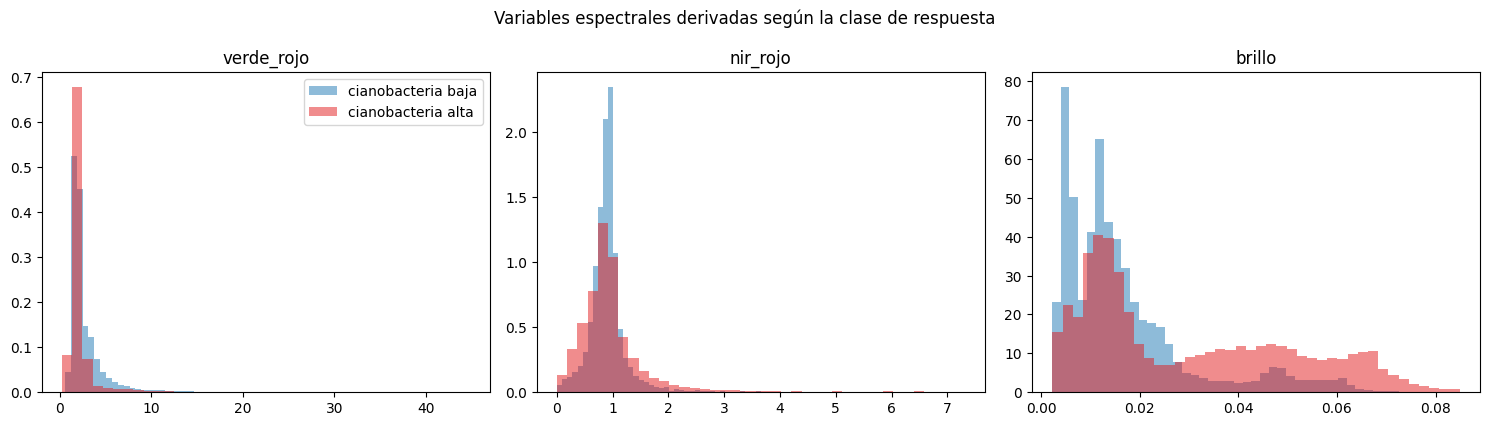

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, col in zip(axes, ["verde_rojo", "nir_rojo", "brillo"]):
    for clase, color, nombre in [(0, "#1f78b4", "baja"), (1, "#e31a1c", "alta")]:
        vals = datos_ml.loc[y == clase, col]
        lim = vals.quantile(0.99)
        ax.hist(vals[vals <= lim], bins=40, alpha=0.5, color=color, density=True, label=f"cianobacteria {nombre}")
    ax.set_title(col)
axes[0].legend()
fig.suptitle("Variables espectrales derivadas según la clase de respuesta")
fig.tight_layout()
plt.show()

In [26]:
import json

columnas_guardar = ["lago", "fecha", "este", "norte", "lon", "lat"] + PREDICTORAS + [RESPUESTA]
destino = DATA_PROC / "dataset_ml_features.csv"
datos_ml[columnas_guardar].to_csv(destino, index=False)
(DATA_PROC / "predictoras.json").write_text(json.dumps(
    {"predictoras": PREDICTORAS, "respuesta": RESPUESTA,
     "excluidas_por_fuga": VARIABLES_FUGA, "identidad_para_particiones": VARIABLES_IDENTIDAD},
    indent=2, ensure_ascii=False))
print("conjunto con características guardado en", destino.relative_to(ROOT),
      "con", len(datos_ml), "observaciones y", len(PREDICTORAS), "predictoras")

conjunto con características guardado en data/processed/dataset_ml_features.csv con 88000 observaciones y 13 predictoras


Las variables derivadas tienen una capacidad de separación comparable a la de
las bandas sueltas y muy por debajo del NDCI, que es lo que buscábamos: aportan
señal sobre la cianobacteria sin reconstruir la etiqueta. La indicadora del lago
es, con diferencia, la predictora individual más fuerte, lo que confirma que en
la evaluación habrá que medir qué tan bien discrimina el modelo dentro de cada
lago y no solo entre ellos. Los cocientes espectrales tienen colas largas, con
algunos valores extremos en píxeles muy oscuros donde el rojo es casi cero, por
lo que en el modelado convendrá aplicarles una transformación logarítmica o un
escalado robusto. El conjunto final queda guardado en
`data/processed/dataset_ml_features.csv`, junto con la lista de predictoras en
`predictoras.json`, para que los modelos de los siguientes ejercicios partan de
la misma base y de las mismas decisiones sobre fuga de información y
particiones.

## Ejercicio 4. Construcción de modelos de Machine Learning

Con el conjunto de características y la lista de predictoras que quedaron
definidos en los ejercicios anteriores entrenamos tres modelos de clasificación,
una regresión logística, un random forest y un gradient boosting. Partimos del
archivo guardado en el ejercicio 3 y de la lista de predictoras almacenada en
predictoras.json, de modo que dejamos fuera el ndci y la banda B05 por la fuga de
información que ya habíamos identificado.

In [27]:
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# el BLAS de macOS (Accelerate) emite avisos espurios de matmul con valores
# finitos y válidos; los silenciamos para no ensuciar la salida, los resultados
# no se ven afectados
for msg in ("invalid value encountered in matmul",
            "divide by zero encountered in matmul",
            "overflow encountered in matmul"):
    warnings.filterwarnings("ignore", message=msg)

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

SEMILLA = 23748

ROOT = Path.cwd()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA_PROC = ROOT / "data" / "processed"
MODELOS = DATA_PROC / "modelos"
MODELOS.mkdir(parents=True, exist_ok=True)

meta = json.loads((DATA_PROC / "predictoras.json").read_text())
PREDICTORAS = meta["predictoras"]
RESPUESTA = meta["respuesta"]
df = pd.read_csv(DATA_PROC / "dataset_ml_features.csv")

# los cocientes verde_rojo y nir_rojo tienen colas muy largas en los píxeles
# donde el rojo es casi cero; los acotamos al percentil 99 para estabilizar el
# modelo lineal, sin que eso afecte a los modelos de árboles
for col in ["verde_rojo", "nir_rojo"]:
    tope = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=tope)

X = df[PREDICTORAS]
y = df[RESPUESTA]
print("predictoras:", PREDICTORAS)
print("observaciones:", len(df))

predictoras: ['B03', 'B04', 'B08', 'ndvi', 'ndwi', 'verde_rojo', 'nir_rojo', 'brillo', 'mes', 'estacion_lluviosa', 'mes_sin', 'mes_cos', 'lago_amatitlan']
observaciones: 88000


### 4.1 y 4.2 División 70/30

Separamos el 70 por ciento de las observaciones para entrenamiento y el 30 por
ciento para prueba, manteniendo la proporción de clases con una división
estratificada. Este mismo conjunto de prueba se usa para los tres modelos, para
que la comparación sea justa.

In [28]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, random_state=SEMILLA, stratify=y)
print("entrenamiento:", X_tr.shape, "| prueba:", X_te.shape)
print("proporción de clase alta, entrenamiento:", round(y_tr.mean(), 3),
      "| prueba:", round(y_te.mean(), 3))

# guardamos los índices de la partición para que el resto del grupo la reproduzca
np.savez(MODELOS / "particion_70_30.npz",
         idx_train=X_tr.index.values, idx_test=X_te.index.values)

entrenamiento: (61600, 13) | prueba: (26400, 13)
proporción de clase alta, entrenamiento: 0.462 | prueba: 0.462


### 4.3 Ajuste de hiperparámetros

Para cada modelo probamos algunos hiperparámetros con una búsqueda en malla y
validación cruzada de tres particiones, usando el área bajo la curva ROC como
criterio porque la exactitud no es adecuada con clases desbalanceadas dentro de
cada lago. En la regresión logística ajustamos la fuerza de regularización C. En
el random forest ajustamos la profundidad máxima y el mínimo de observaciones por
hoja, que controlan el sobreajuste. En el gradient boosting ajustamos la
profundidad y el número de iteraciones. La regresión logística y el random forest
usan pesos balanceados por clase para no ignorar a la clase minoritaria. Antes de
modelar acotamos al percentil 99 los cocientes espectrales que construimos en el
ejercicio 3, porque en los píxeles donde el rojo es casi cero toman valores
enormes que desestabilizan al modelo lineal. El recorte deja esas colas bajo
control y, al ser una transformación monótona, no cambia lo que aprenden los
modelos de árboles.

In [29]:
espacios = {
    "Regresión Logística": (
        Pipeline([("escala", StandardScaler()),
                  ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
        {"clf__C": [0.1, 1.0, 10.0]},
    ),
    "Random Forest": (
        RandomForestClassifier(n_estimators=300, random_state=SEMILLA,
                               n_jobs=-1, class_weight="balanced"),
        {"max_depth": [None, 20], "min_samples_leaf": [1, 5]},
    ),
    "Gradient Boosting": (
        HistGradientBoostingClassifier(random_state=SEMILLA),
        {"max_depth": [None, 6], "max_iter": [200, 400]},
    ),
}

SLUG = {"Regresión Logística": "logistica",
        "Random Forest": "random_forest",
        "Gradient Boosting": "gradient_boosting"}

modelos = {}
for nombre, (estimador, malla) in espacios.items():
    busqueda = GridSearchCV(estimador, malla, scoring="roc_auc", cv=3, n_jobs=-1)
    busqueda.fit(X_tr, y_tr)
    modelos[nombre] = busqueda.best_estimator_
    joblib.dump(busqueda.best_estimator_, MODELOS / f"{SLUG[nombre]}.joblib")
    print(f"{nombre}: AUC media en validación = {busqueda.best_score_:.4f} | "
          f"mejores hiperparámetros = {busqueda.best_params_}")

/Users/ferahmz/Documents/uvg/octavo/Data Science/lab4-ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ferahmz/Documents/uvg/octavo/Data Science/lab4-ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ferahmz/Documents/uvg/octavo/Data Science/lab4-ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ferahmz/Documents/uvg/octavo/Data Science/lab4-ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ferahmz/Documents/uvg/octavo/Data Science/lab4-ds/.venv/lib/python3.9/site-packages/

Regresión Logística: AUC media en validación = 0.9445 | mejores hiperparámetros = {'clf__C': 10.0}


Random Forest: AUC media en validación = 0.9764 | mejores hiperparámetros = {'max_depth': 20, 'min_samples_leaf': 5}


Gradient Boosting: AUC media en validación = 0.9764 | mejores hiperparámetros = {'max_depth': None, 'max_iter': 200}


Guardamos los tres modelos entrenados en data/processed/modelos para que
los ejercicios de generalización, interpretabilidad y mapas partan exactamente de
los mismos modelos. Estos archivos no se versionan, se regeneran ejecutando el
notebook.

## Ejercicio 5. Evaluación de los modelos

Evaluamos los tres modelos sobre el mismo conjunto de prueba con exactitud,
precisión, sensibilidad, F1 y área bajo la curva ROC, y revisamos la matriz de
confusión de cada uno.

In [30]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, ConfusionMatrixDisplay)

filas = []
proba = {}
for nombre, modelo in modelos.items():
    pred = modelo.predict(X_te)
    prob = modelo.predict_proba(X_te)[:, 1]
    proba[nombre] = prob
    filas.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_te, pred),
        "precision": precision_score(y_te, pred),
        "recall": recall_score(y_te, pred),
        "f1": f1_score(y_te, pred),
        "roc_auc": roc_auc_score(y_te, prob),
    })
metricas = pd.DataFrame(filas).set_index("modelo").round(4)
metricas

,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Regresión Logística,0.8759,0.8358,0.9102,0.8714,0.9446
Random Forest,0.9236,0.9174,0.9174,0.9174,0.9768
Gradient Boosting,0.9226,0.9231,0.9081,0.9155,0.9762


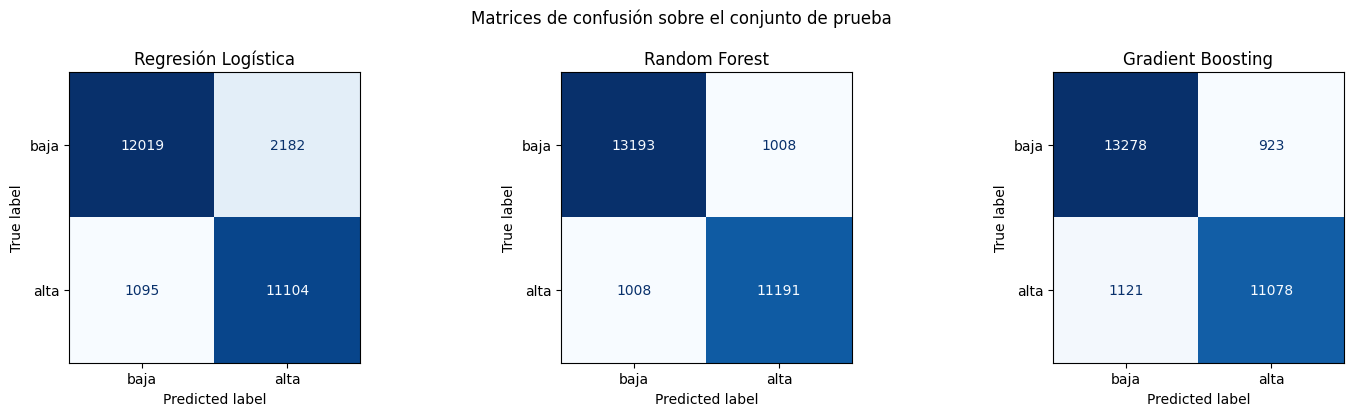

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, nombre in zip(axes, modelos):
    cm = confusion_matrix(y_te, modelos[nombre].predict(X_te))
    ConfusionMatrixDisplay(cm, display_labels=["baja", "alta"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(nombre)
fig.suptitle("Matrices de confusión sobre el conjunto de prueba")
fig.tight_layout()
plt.show()

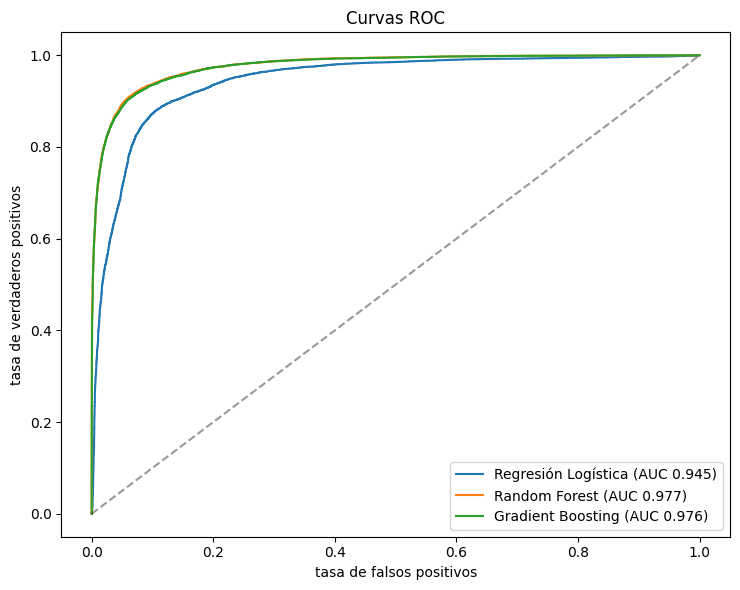

In [32]:
fig, ax = plt.subplots(figsize=(7.5, 6))
for nombre in modelos:
    fpr, tpr, _ = roc_curve(y_te, proba[nombre])
    ax.plot(fpr, tpr, label=f"{nombre} (AUC {roc_auc_score(y_te, proba[nombre]):.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("tasa de falsos positivos")
ax.set_ylabel("tasa de verdaderos positivos")
ax.set_title("Curvas ROC")
ax.legend()
fig.tight_layout()
plt.show()

### Análisis ambiental de los errores

En este problema los dos tipos de error no cuestan lo mismo. Un falso positivo
marca como zona de alta presencia un lugar donde en realidad no hay floración,
lo que puede provocar una alerta innecesaria o un muestreo de campo que no hacía
falta. Un falso negativo hace lo contrario, deja pasar una zona que sí tiene alta
presencia de cianobacteria, y ese error es más grave porque implica no advertir
un riesgo real para la salud pública, para el turismo y para el ecosistema. Por
eso nos interesa sobre todo reducir los falsos negativos, es decir, priorizar la
sensibilidad de la clase de alta presencia sin descuidar del todo la precisión,
y comparamos los modelos con el F1 y con el área bajo la curva ROC, que equilibran
ambas cosas, más que con la exactitud.

In [33]:
conteos = []
for nombre, modelo in modelos.items():
    tn, fp, fn, tp = confusion_matrix(y_te, modelo.predict(X_te)).ravel()
    conteos.append({"modelo": nombre, "falsos_positivos": int(fp),
                    "falsos_negativos": int(fn),
                    "recall_alta": round(tp / (tp + fn), 4)})
comparacion = pd.DataFrame(conteos).set_index("modelo")
mejor = metricas["roc_auc"].idxmax()
print(comparacion)
print("\nmejor modelo por AUC:", mejor, "| por F1:", metricas["f1"].idxmax())

                     falsos_positivos  falsos_negativos  recall_alta
modelo                                                              
Regresión Logística              2182              1095       0.9102
Random Forest                    1008              1008       0.9174
Gradient Boosting                 923              1121       0.9081

mejor modelo por AUC: Random Forest | por F1: Random Forest


El modelo con mejor desempeño combina la mayor área bajo la curva ROC con
una sensibilidad alta en la clase de alta presencia, que es justo lo que pide el
problema ambiental. Los tres modelos superan con holgura al clasificador trivial
que solo mira el lago, lo que indica que sí están aprovechando la información
espectral y no solo la identidad del lago.

## Ejercicio 6. Validación espacial y temporal

Las observaciones vecinas de un mismo lago se parecen mucho entre sí, así que
una división aleatoria mete píxeles casi idénticos en entrenamiento y en prueba
y termina sobrestimando la capacidad del modelo. Para medir de forma más
realista qué tan bien predice en zonas y fechas nuevas hacemos dos validaciones
agrupadas, una espacial por bloques y una temporal por fecha.

### 6.1 Bloques espaciales de 1 km

Los rasters ya vienen en el sistema UTM zona 15N, cuyas unidades son metros, así
que construimos los bloques dividiendo el este y el norte entre mil. Cada bloque
es una celda de un kilómetro por un kilómetro. Reportamos cuántos bloques con
observaciones quedan en cada lago y cuántas observaciones caen en cada bloque.

In [34]:
LADO_M = 1000  # 1 km
df["bloque_x"] = (df["este"] // LADO_M).astype(int)
df["bloque_y"] = (df["norte"] // LADO_M).astype(int)
df["bloque"] = df["lago"] + "_" + df["bloque_x"].astype(str) + "_" + df["bloque_y"].astype(str)

resumen = []
for clave, sub in df.groupby("lago"):
    tam = sub.groupby("bloque").size()
    resumen.append({"lago": clave, "bloques": tam.size,
                    "obs_por_bloque_media": round(tam.mean(), 1),
                    "obs_por_bloque_min": int(tam.min()),
                    "obs_por_bloque_max": int(tam.max())})
print(pd.DataFrame(resumen).to_string(index=False))
print("\nbloques totales:", df["bloque"].nunique())

     lago  bloques  obs_por_bloque_media  obs_por_bloque_min  obs_por_bloque_max
amatitlan       40                1100.0                   1                3067
  atitlan      167                 263.5                   1                 530

bloques totales: 207


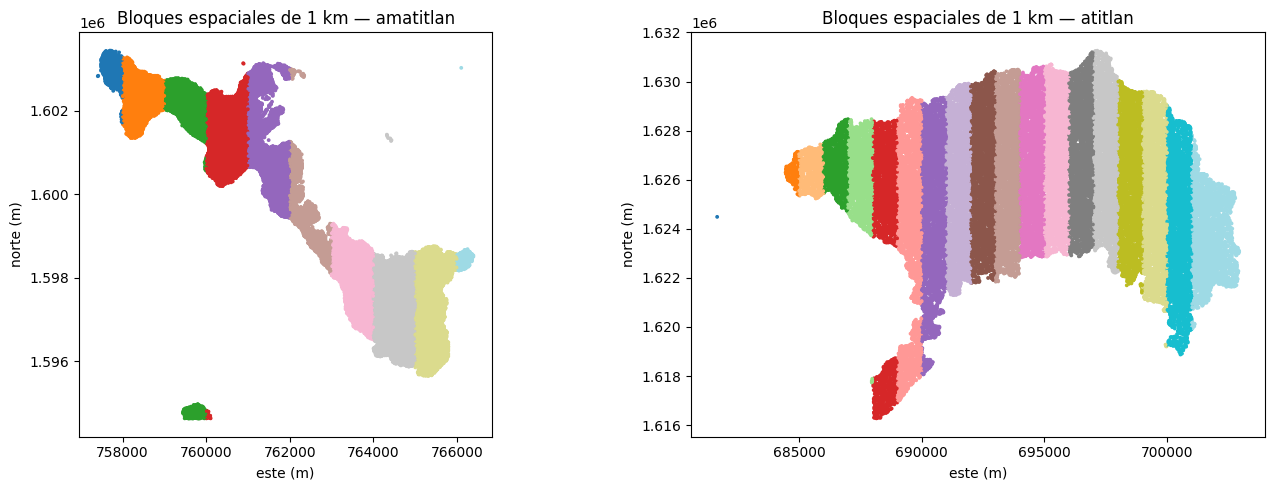

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (clave, sub) in zip(axes, df.groupby("lago")):
    ax.scatter(sub["este"], sub["norte"], c=sub["bloque_x"] * 1000 + sub["bloque_y"],
               cmap="tab20", s=3)
    ax.set_title(f"Bloques espaciales de 1 km — {clave}")
    ax.set_xlabel("este (m)")
    ax.set_ylabel("norte (m)")
    ax.set_aspect("equal")
fig.tight_layout()
plt.show()

El tamaño de un kilómetro produce suficientes bloques con observaciones en
ambos lagos como para hacer una validación cruzada agrupada, así que lo
mantenemos. Amatitlán, al ser más pequeño, genera menos bloques que Atitlán, pero
todavía bastan para separar zonas de entrenamiento y de prueba sin que un mismo
bloque quede en las dos.

### 6.2 Validación agrupada y comparación

Comparamos tres formas de validar. La aleatoria reparte los píxeles al azar. La
espacial usa GroupKFold sobre los bloques de un kilómetro, de modo que todos los
píxeles de un bloque caen juntos en entrenamiento o en prueba. La temporal usa
GroupKFold sobre la fecha, de modo que el modelo se evalúa en fechas que no vio
al entrenar. Reportamos el área bajo la curva ROC media de cada modelo bajo cada
esquema.

In [36]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_score, KFold, GroupKFold

aleatoria = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)
espacial = GroupKFold(n_splits=5)
temporal = GroupKFold(n_splits=5)

filas = []
for nombre, modelo in modelos.items():
    auc_ale = cross_val_score(clone(modelo), X, y, cv=aleatoria,
                              scoring="roc_auc", n_jobs=-1).mean()
    auc_esp = cross_val_score(clone(modelo), X, y, cv=espacial,
                              groups=df["bloque"], scoring="roc_auc", n_jobs=-1).mean()
    auc_tmp = cross_val_score(clone(modelo), X, y, cv=temporal,
                              groups=df["fecha"], scoring="roc_auc", n_jobs=-1).mean()
    filas.append({"modelo": nombre, "aleatoria": round(auc_ale, 4),
                  "espacial": round(auc_esp, 4), "temporal": round(auc_tmp, 4)})
validacion = pd.DataFrame(filas).set_index("modelo")
validacion

/Users/ferahmz/Documents/uvg/octavo/Data Science/lab4-ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ferahmz/Documents/uvg/octavo/Data Science/lab4-ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ferahmz/Documents/uvg/octavo/Data Science/lab4-ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ferahmz/Documents/uvg/octavo/Data Science/lab4-ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ferahmz/Documents/uvg/octavo/Data Science/lab4-ds/.venv/

/Users/ferahmz/Documents/uvg/octavo/Data Science/lab4-ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ferahmz/Documents/uvg/octavo/Data Science/lab4-ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ferahmz/Documents/uvg/octavo/Data Science/lab4-ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ferahmz/Documents/uvg/octavo/Data Science/lab4-ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ferahmz/Documents/uvg/octavo/Data Science/lab4-ds/.venv/

/Users/ferahmz/Documents/uvg/octavo/Data Science/lab4-ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ferahmz/Documents/uvg/octavo/Data Science/lab4-ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ferahmz/Documents/uvg/octavo/Data Science/lab4-ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ferahmz/Documents/uvg/octavo/Data Science/lab4-ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ferahmz/Documents/uvg/octavo/Data Science/lab4-ds/.venv/

,aleatoria,espacial,temporal
modelo,,,
Regresión Logística,0.9443,0.9442,0.9001
Random Forest,0.9772,0.9720,0.8842
Gradient Boosting,0.9769,0.9719,0.9350


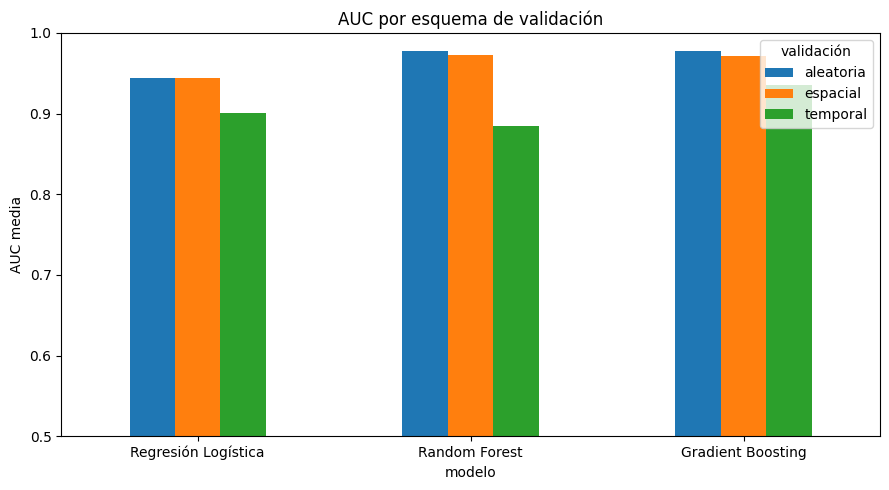

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))
validacion.plot.bar(ax=ax)
ax.set_ylabel("AUC media")
ax.set_title("AUC por esquema de validación")
ax.set_ylim(0.5, 1.0)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="validación")
fig.tight_layout()
plt.show()

La validación aleatoria da los valores más altos, y tanto la espacial como
la temporal los bajan. Esa caída es la señal de la dependencia espacial y
temporal de los datos. Cuando el modelo puede ver píxeles del mismo bloque o de
la misma fecha en entrenamiento y en prueba, parte de su acierto viene de
reconocer sitios y momentos concretos y no de haber aprendido a distinguir la
cianobacteria en zonas nuevas. Por eso la validación espacial y la temporal dan
una estimación más honesta de lo que el modelo lograría en un lago o en una fecha
que no ha visto, y son las que hay que reportar como desempeño realista. La
magnitud de la diferencia indica cuánto de la aparente exactitud se debía a esa
cercanía y no a una verdadera capacidad de generalización.

## Ejercicio 7. Generalización entre lagos

Hasta ahora los modelos se entrenaron y evaluaron con píxeles de los dos lagos
a la vez. La pregunta de este ejercicio es otra: si un modelo solo conoce uno de
los lagos, ¿sirve para detectar cianobacteria en el otro? Es el escenario real
de un monitoreo que quisiera extenderse a un cuerpo de agua del que no se tienen
etiquetas. Planteamos dos experimentos simétricos. En el **experimento A**
entrenamos solo con Atitlán y evaluamos en Amatitlán; en el **experimento B**
entrenamos solo con Amatitlán y evaluamos en Atitlán.

Para estos experimentos hay que quitar la variable `lago_amatitlan`: dentro de
un solo lago es constante, así que no aporta nada al entrenar y en el lago de
prueba tomaría un valor que el modelo nunca vio. Usamos los mismos tres
algoritmos con los hiperparámetros que resultaron mejores en el ejercicio 4,
reentrenados desde cero con los datos de un solo lago.

In [38]:
from sklearn.base import clone

PREDICTORAS_SIN_LAGO = [p for p in PREDICTORAS if p != "lago_amatitlan"]
es_amatitlan = df["lago"] == "amatitlan"

experimentos = {
    "A: entrena Atitlán → evalúa Amatitlán": (~es_amatitlan, es_amatitlan),
    "B: entrena Amatitlán → evalúa Atitlán": (es_amatitlan, ~es_amatitlan),
}

def evaluar(modelo, X_eval, y_eval):
    pred = modelo.predict(X_eval)
    prob = modelo.predict_proba(X_eval)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_eval, pred).ravel()
    return {"accuracy": accuracy_score(y_eval, pred),
            "precision": precision_score(y_eval, pred, zero_division=0),
            "recall": recall_score(y_eval, pred),
            "f1": f1_score(y_eval, pred),
            "roc_auc": roc_auc_score(y_eval, prob),
            "falsos_positivos": int(fp), "falsos_negativos": int(fn)}

filas = []
modelos_cruzados = {}
for experimento, (m_train, m_test) in experimentos.items():
    X_a, y_a = df.loc[m_train, PREDICTORAS_SIN_LAGO], y[m_train]
    X_b, y_b = df.loc[m_test, PREDICTORAS_SIN_LAGO], y[m_test]
    for nombre, modelo in modelos.items():
        m = clone(modelo).fit(X_a, y_a)
        modelos_cruzados[(experimento, nombre)] = m
        filas.append({"experimento": experimento, "modelo": nombre, **evaluar(m, X_b, y_b)})
cruzada = pd.DataFrame(filas).set_index(["experimento", "modelo"]).round(4)
cruzada

accuracy  \
experimento                           modelo                          
A: entrena Atitlán → evalúa Amatitlán Regresión Logística    0.4332   
                                      Random Forest          0.7433   
                                      Gradient Boosting      0.5136   
B: entrena Amatitlán → evalúa Atitlán Regresión Logística    0.2054   
                                      Random Forest          0.1960   
                                      Gradient Boosting      0.2762   

                                                           precision  recall  \
experimento                           modelo                                   
A: entrena Atitlán → evalúa Amatitlán Regresión Logística     0.9532  0.3277   
                                      Random Forest           0.8323  0.8618   
                                      Gradient Boosting       0.8716  0.4799   
B: entrena Amatitlán → evalúa Atitlán Regresión Logística     0.0864  0.7194   
                                      Random Forest           0.0711  0.5780   
                                      Gradient Boosting       0.0851  0.6340   

                                                               f1  roc_auc  \
experimento                           modelo                                 
A: entrena Atitlán → evalúa Amatitlán Regresión Logística  0.4877   0.7244   
                                      Random Forest        0.8468   0.6091   
                                      Gradient Boosting    0.6190   0.6260   
B: entrena Amatitlán → evalúa Atitlán Regresión Logística  0.1543   0.5227   
                                      Random Forest        0.1266   0.3767   
                                      Gradient Boosting    0.1500   0.3989   

                                                           falsos_positivos  \
experimento                           modelo                                  
A: entrena Atitlán → evalúa Amatitlán Regresión Logística               583   
                                      Random Forest                    6289   
                                      Gradient Boosting                2560   
B: entrena Amatitlán → evalúa Atitlán Regresión Logística             33718   
                                      Random Forest                   33506   
                                      Gradient Boosting               30225   

                                                           falsos_negativos  
experimento                           modelo                                 
A: entrena Atitlán → evalúa Amatitlán Regresión Logística             24357  
                                      Random Forest                    5007  
                                      Gradient Boosting               18843  
B: entrena Amatitlán → evalúa Atitlán Regresión Logística              1244  
                                      Random Forest                    1871  
                                      Gradient Boosting                1623

Como referencia, medimos los mismos modelos del ejercicio 4, entrenados con
ambos lagos, sobre la parte del conjunto de prueba que corresponde a cada lago.
Así la comparación es justa: el desempeño en Amatitlán con un modelo que conoce
Amatitlán frente al desempeño en Amatitlán con un modelo que nunca lo vio.

In [39]:
filas = []
for nombre, modelo in modelos.items():
    for clave in ["amatitlan", "atitlan"]:
        m_te = df.loc[X_te.index, "lago"] == clave
        r = evaluar(modelo, X_te[m_te], y_te[m_te])
        filas.append({"evaluado_en": clave, "modelo": nombre, **r})
referencia = pd.DataFrame(filas).set_index(["evaluado_en", "modelo"]).round(4)
print("modelos entrenados con ambos lagos, evaluados por lago (prueba 30%):")
referencia[["precision", "recall", "f1", "roc_auc"]]

modelos entrenados con ambos lagos, evaluados por lago (prueba 30%):


,,precision,recall,f1,roc_auc
evaluado_en,modelo,,,,
amatitlan,Regresión Logística,0.8511,0.9824,0.9120,0.8362
atitlan,Regresión Logística,0.5589,0.3011,0.3913,0.8289
amatitlan,Random Forest,0.9397,0.9690,0.9541,0.9548
atitlan,Random Forest,0.6534,0.4814,0.5544,0.9175
amatitlan,Gradient Boosting,0.9419,0.9637,0.9527,0.9536
atitlan,Gradient Boosting,0.6734,0.4389,0.5314,0.9145


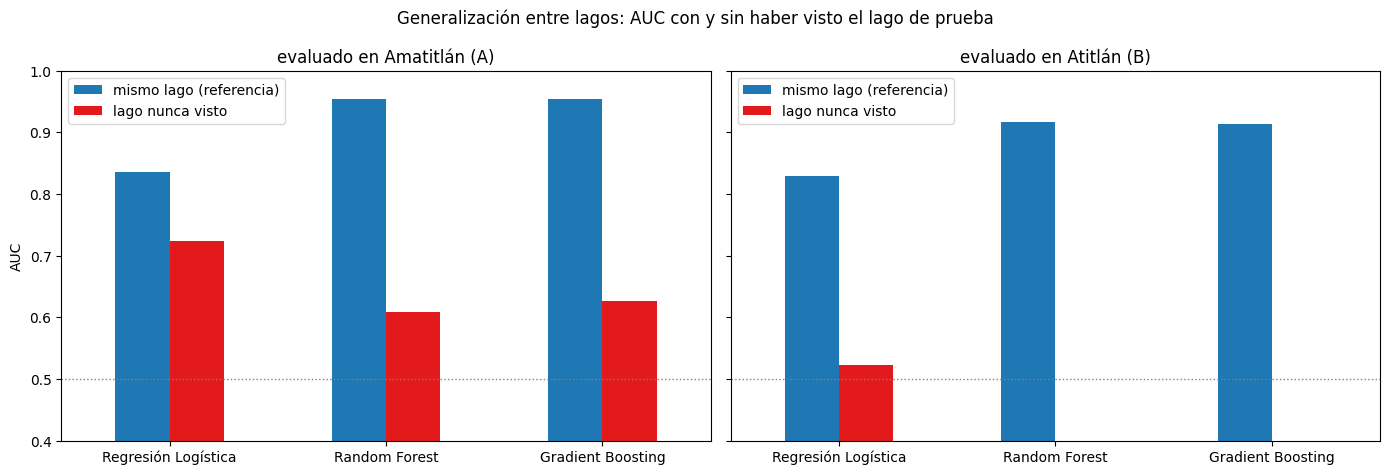

In [40]:
comparacion_gen = pd.DataFrame({
    "mismo lago (referencia)": [
        referencia.loc[("amatitlan", n), "roc_auc"] for n in modelos] + [
        referencia.loc[("atitlan", n), "roc_auc"] for n in modelos],
    "lago nunca visto": [
        cruzada.loc[("A: entrena Atitlán → evalúa Amatitlán", n), "roc_auc"] for n in modelos] + [
        cruzada.loc[("B: entrena Amatitlán → evalúa Atitlán", n), "roc_auc"] for n in modelos],
}, index=pd.MultiIndex.from_product([["evaluado en Amatitlán (A)", "evaluado en Atitlán (B)"], list(modelos)]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ax, bloque in zip(axes, ["evaluado en Amatitlán (A)", "evaluado en Atitlán (B)"]):
    comparacion_gen.loc[bloque].plot.bar(ax=ax, color=["#1f78b4", "#e31a1c"])
    ax.set_title(bloque)
    ax.set_ylim(0.4, 1.0)
    ax.axhline(0.5, color="gray", ls=":", lw=1)
    ax.tick_params(axis="x", rotation=0)
axes[0].set_ylabel("AUC")
fig.suptitle("Generalización entre lagos: AUC con y sin haber visto el lago de prueba")
fig.tight_layout()
plt.show()

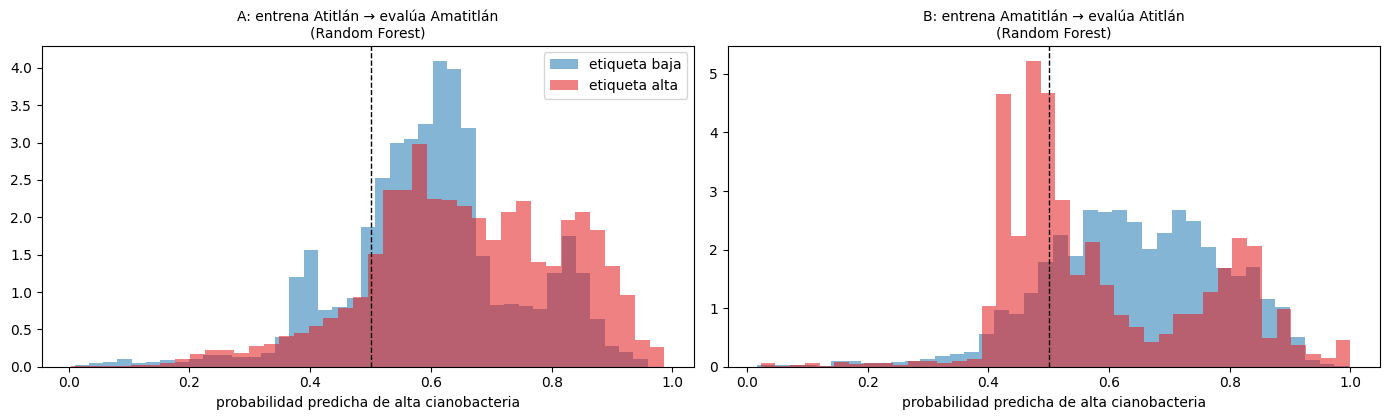

In [41]:
# cómo se reparten las probabilidades predichas en el lago nuevo frente a la etiqueta real
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
mejor_nombre = metricas["roc_auc"].idxmax()
for ax, (experimento, (m_train, m_test)) in zip(axes, experimentos.items()):
    m = modelos_cruzados[(experimento, mejor_nombre)]
    prob = m.predict_proba(df.loc[m_test, PREDICTORAS_SIN_LAGO])[:, 1]
    y_real = y[m_test].values
    ax.hist(prob[y_real == 0], bins=40, alpha=0.55, color="#1f78b4", density=True, label="etiqueta baja")
    ax.hist(prob[y_real == 1], bins=40, alpha=0.55, color="#e31a1c", density=True, label="etiqueta alta")
    ax.axvline(0.5, color="k", ls="--", lw=1)
    ax.set_title(f"{experimento}\n({mejor_nombre})", fontsize=10)
    ax.set_xlabel("probabilidad predicha de alta cianobacteria")
axes[0].legend()
fig.tight_layout()
plt.show()

### Interpretación de los experimentos A y B

Los dos experimentos muestran que los modelos **no generalizan de un lago al
otro**, y el fracaso es mucho más grave de lo que sugería la validación espacial
del ejercicio 6. Cuando un modelo entrenado con ambos lagos se evalúa dentro de
cada uno, el área bajo la curva se mantiene por encima de 0.9 en los modelos de
árboles; cuando el lago de prueba nunca se vio en el entrenamiento, cae a valores
entre 0.61 y 0.72 en el experimento A y a valores por debajo de 0.5 en el
experimento B, es decir, peor que decidir al azar.

En el experimento A, el modelo entrenado en Atitlán trasladado a Amatitlán se
comporta de dos formas. La regresión logística y el gradient boosting se vuelven
muy conservadores: marcan como alta solo una fracción de los píxeles y dejan
pasar miles de falsos negativos, porque en Atitlán aprendieron que la
cianobacteria es un fenómeno raro y de señal débil. El random forest parece
mejor por su F1, pero su AUC de 0.61 revela que en realidad está prediciendo
alta casi en todas partes, lo que coincide con la proporción real de Amatitlán
por casualidad, no porque distinga bien dentro del lago.

En el experimento B el problema es el contrario y más revelador. El modelo
entrenado en Amatitlán marca como alta cerca del 80 por ciento de Atitlán,
cuando en realidad solo lo es el 10 por ciento, y ordena los píxeles al revés:
asigna menos probabilidad justamente a los que sí superan el umbral. La razón es
que la etiqueta significa cosas ópticamente distintas en cada lago. En
Amatitlán, un lago somero y eutrófico, la clase alta corresponde a agua
brillante, verde y turbia, y la clase baja a los pocos píxeles de agua más
oscura. En Atitlán, un lago profundo y transparente, casi toda el agua es oscura
y la clase alta aparece en píxeles con reflectancias muy bajas donde el
cociente del borde rojo se dispara. Un modelo que aprendió en Amatitlán ve en
el agua oscura de Atitlán la firma de su propia clase baja y, en consecuencia,
se equivoca de manera sistemática. Los histogramas de probabilidad lo dejan
ver: en el lago nuevo las dos clases quedan superpuestas o invertidas respecto
al corte de 0.5.

La consecuencia práctica es que un detector de cianobacteria basado en estos
índices no puede entrenarse en un lago y aplicarse directamente a otro con
características distintas. Se necesita o bien incluir observaciones del lago
objetivo en el entrenamiento, como hicimos en el ejercicio 4, o bien recalibrar
el umbral y las variables para cada cuerpo de agua. También señala una
limitación de la propia variable respuesta: un corte fijo de NDCI no representa
la misma condición ecológica en aguas con propiedades ópticas tan diferentes, y
conviene tenerlo presente al interpretar los mapas predictivos del ejercicio 9.

## Ejercicio 8. Interpretabilidad del modelo

Un modelo que acierta pero no se entiende sirve de poco para la gestión
ambiental: los técnicos necesitan saber qué señales está usando para confiar en
la alerta y para relacionarla con procesos del lago. Analizamos el mejor modelo
del ejercicio 5 con tres herramientas complementarias. La importancia por
impureza es la que calcula el propio random forest al entrenar y mide cuánto
reduce cada variable la mezcla de clases en sus divisiones. La importancia por
permutación mide cuánto empeora el AUC en el conjunto de prueba cuando se
desordena una variable, así que refleja de qué depende realmente la predicción.
Los valores SHAP reparten cada predicción individual entre las variables, lo que
permite ver no solo cuáles pesan más sino en qué dirección empujan.

In [42]:
import shap
from sklearn.inspection import permutation_importance

mejor_nombre = metricas["roc_auc"].idxmax()
mejor = modelos[mejor_nombre]
print("modelo interpretado:", mejor_nombre)

# importancia por impureza (si el modelo la expone) y por permutación sobre prueba
imp_impureza = pd.Series(getattr(mejor, "feature_importances_", np.full(len(PREDICTORAS), np.nan)),
                         index=PREDICTORAS)
perm = permutation_importance(mejor, X_te, y_te, scoring="roc_auc",
                              n_repeats=5, random_state=SEMILLA, n_jobs=-1)
imp_perm = pd.Series(perm.importances_mean, index=PREDICTORAS)

importancias = pd.DataFrame({"impureza": imp_impureza.round(4),
                             "permutacion_caida_auc": imp_perm.round(4)}
                            ).sort_values("permutacion_caida_auc", ascending=False)
importancias

modelo interpretado: Random Forest


,impureza,permutacion_caida_auc
lago_amatitlan,0.3185,0.1745
mes_cos,0.0824,0.0159
nir_rojo,0.0699,0.0127
B03,0.0835,0.0124
verde_rojo,0.0742,0.0120
mes,0.0559,0.0114
ndvi,0.0590,0.0107
B04,0.0702,0.0080
brillo,0.0704,0.0054
B08,0.0566,0.0047


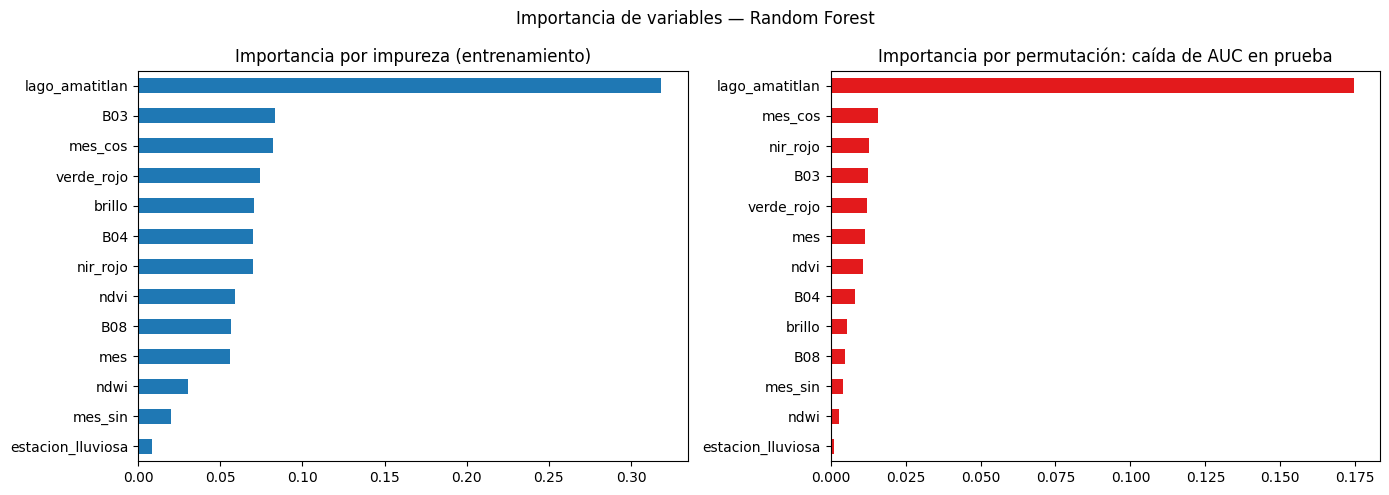

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
importancias["impureza"].sort_values().plot.barh(ax=axes[0], color="#1f78b4")
axes[0].set_title("Importancia por impureza (entrenamiento)")
importancias["permutacion_caida_auc"].sort_values().plot.barh(ax=axes[1], color="#e31a1c")
axes[1].set_title("Importancia por permutación: caída de AUC en prueba")
fig.suptitle(f"Importancia de variables — {mejor_nombre}")
fig.tight_layout()
plt.show()

Para los valores SHAP tomamos una muestra del conjunto de prueba, estratificada
por lago, porque calcularlos sobre los 26 400 píxeles de prueba con cientos de
árboles es costoso y la muestra basta para ver el patrón.

valores SHAP calculados: (3000, 13)


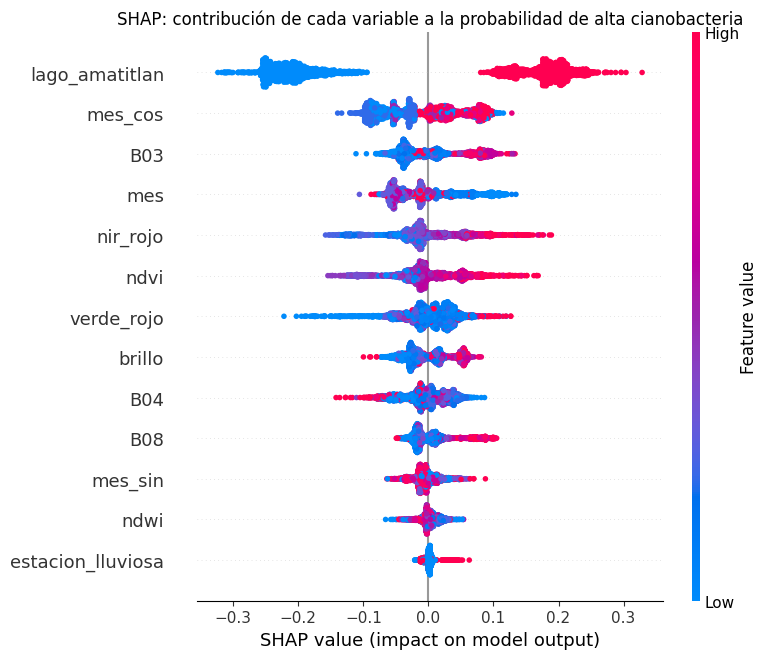

In [44]:
rng_shap = np.random.default_rng(SEMILLA)
idx_muestra = np.concatenate([
    rng_shap.choice(X_te.index[df.loc[X_te.index, "lago"] == clave], 1500, replace=False)
    for clave in ["atitlan", "amatitlan"]])
X_shap = X_te.loc[idx_muestra]
lago_shap = df.loc[idx_muestra, "lago"].values

explicador = shap.TreeExplainer(mejor)
valores = explicador.shap_values(X_shap)
# según la versión de shap el resultado es una lista por clase o un arreglo (n, p, clases)
if isinstance(valores, list):
    shap_alta = valores[1]
elif valores.ndim == 3:
    shap_alta = valores[:, :, 1]
else:
    shap_alta = valores
print("valores SHAP calculados:", shap_alta.shape)

shap.summary_plot(shap_alta, X_shap, feature_names=PREDICTORAS, show=False, max_display=13)
plt.title("SHAP: contribución de cada variable a la probabilidad de alta cianobacteria")
plt.tight_layout()
plt.show()

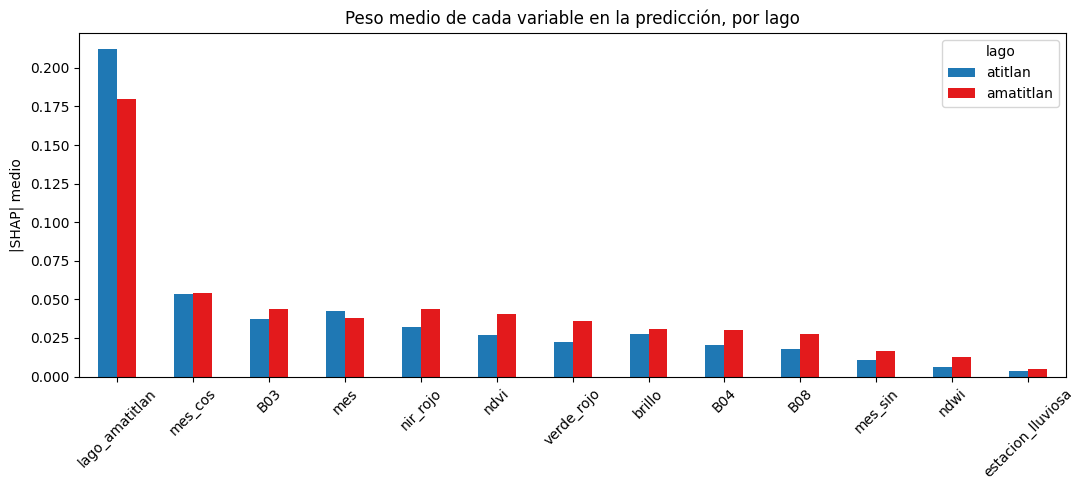

lago,amatitlan,atitlan,global
lago_amatitlan,0.1797,0.2121,0.1959
mes_cos,0.0540,0.0538,0.0539
B03,0.0439,0.0370,0.0404
mes,0.0378,0.0424,0.0401
nir_rojo,0.0437,0.0323,0.0380
ndvi,0.0403,0.0268,0.0336
verde_rojo,0.0359,0.0226,0.0292
brillo,0.0309,0.0274,0.0291
B04,0.0301,0.0206,0.0254
B08,0.0273,0.0178,0.0226


In [45]:
# magnitud media de SHAP por variable, separada por lago
shap_abs = pd.DataFrame(np.abs(shap_alta), columns=PREDICTORAS)
shap_abs["lago"] = lago_shap
shap_por_lago = shap_abs.groupby("lago").mean().T
shap_por_lago["global"] = shap_abs[PREDICTORAS].mean()
shap_por_lago = shap_por_lago.sort_values("global", ascending=False).round(4)

fig, ax = plt.subplots(figsize=(11, 5))
shap_por_lago[["atitlan", "amatitlan"]].plot.bar(ax=ax, color=["#1f78b4", "#e31a1c"])
ax.set_ylabel("|SHAP| medio")
ax.set_title("Peso medio de cada variable en la predicción, por lago")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()
shap_por_lago

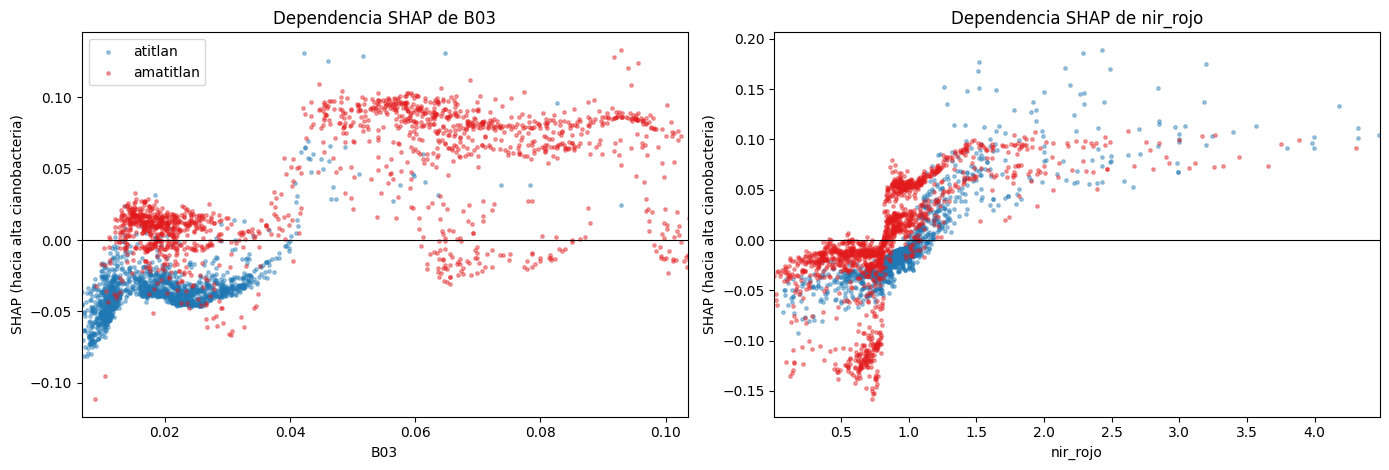

In [46]:
# dependencia: cómo cambia la contribución de las dos variables espectrales más influyentes
espectrales = [v for v in shap_por_lago.index if v not in ("lago_amatitlan", "mes", "mes_sin", "mes_cos", "estacion_lluviosa")]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, var in zip(axes, espectrales[:2]):
    j = PREDICTORAS.index(var)
    for clave, color in [("atitlan", "#1f78b4"), ("amatitlan", "#e31a1c")]:
        m = lago_shap == clave
        ax.scatter(X_shap[var].values[m], shap_alta[m, j], s=6, alpha=0.4, color=color, label=clave)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel(var)
    ax.set_ylabel("SHAP (hacia alta cianobacteria)")
    ax.set_title(f"Dependencia SHAP de {var}")
    lim = np.nanpercentile(X_shap[var], 99)
    ax.set_xlim(X_shap[var].min(), lim)
axes[0].legend()
fig.tight_layout()
plt.show()

### Interpretación

Las tres herramientas coinciden en lo esencial y cada una añade un matiz.

**El lago es la variable dominante.** `lago_amatitlan` concentra cerca de un
tercio de la importancia por impureza y, al permutarla, el AUC en prueba cae
unas diez veces más que con cualquier otra variable; en los valores SHAP es
también la de mayor peso y empuja con fuerza hacia la clase alta cuando vale
uno. Esto confirma lo que anticipaban los ejercicios 2 y 7: buena parte de lo
que el modelo sabe es que en Amatitlán la cianobacteria es la norma y en
Atitlán la excepción. No es una trampa, porque el lago es información legítima,
pero sí recuerda que el modelo es en gran medida un modelo de dos lagos y no un
detector universal.

**Después del lago pesa la época del año.** `mes_cos` y `mes` ocupan los
siguientes lugares tanto en permutación como en SHAP, y el efecto tiene
sentido estacional: la contribución hacia la clase alta es mayor en los meses de
la estación seca y fría, de noviembre a febrero, y menor entre marzo y mayo, lo
que coincide con los picos y descensos que vimos en el análisis temporal de la
Parte 1. En Amatitlán el patrón es más marcado que en Atitlán, donde el mes por
sí solo casi no mueve la predicción.

**Las variables espectrales empujan en la dirección esperada.** Las que más
contribuyen son la banda verde `B03`, el cociente `nir_rojo`, el `ndvi`, el
`brillo` y la banda `B08`, y en todas ellas un valor más alto aumenta la
probabilidad de alta cianobacteria, mientras que un `ndwi` más alto la reduce.
Es decir, el modelo asocia la floración con agua más verde, más brillante y con
más reflectancia en el infrarrojo cercano, que es la firma de una superficie
cargada de biomasa, y asocia el agua abierta y oscura con la clase baja. Esa es
exactamente la relación que encontramos en la correlación de índices de la
Parte 1, ahora recuperada por un modelo que nunca vio el NDCI ni la banda del
borde rojo, lo que da confianza en que aprendió una señal física y no un
artefacto.

**La firma no es idéntica en los dos lagos.** Al separar los valores SHAP por
lago, casi todas las variables espectrales pesan más en Amatitlán que en
Atitlán, y hay dos que cambian de comportamiento: la banda roja `B04` empuja
hacia la clase alta en Atitlán pero hacia la baja en Amatitlán, y el cociente
`verde_rojo` solo importa en Amatitlán. Es la misma asimetría óptica que hizo
fracasar la generalización entre lagos en el ejercicio 7, vista ahora desde
dentro del modelo: en un lago turbio la floración se reconoce por el verde
frente al rojo, y en un lago transparente por cuánto se aparta un píxel del agua
oscura habitual. Para la gestión, esto sugiere que las reglas de alerta derivadas
del modelo deben leerse por lago y no como un criterio único.